## read albu transition matrix

In [475]:
import pandas as pd
import numpy as np
import os

# Path to the folder containing CSV files
folder_path = '../data/albu_transit/'

# Get a list of CSV files in the folder
csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

# Gender and country maps
gender_map = {'male': 0, 'female': 1}
country_map = {'chn': 0, 'ind': 1, 'mal': 2}

# Read all CSV files and store them in a dictionary with names as keys
data_frames = {}
for file_name in csv_files:
    file_path = os.path.join(folder_path, file_name)
    # Extract gender and country from the file name, e.g., male_chn.csv -> gender='male', country='chn'
    gender, country = file_name.split('.')[0].split('_')
    data_frames[(gender, country)] = pd.read_csv(file_path).values  # Store the raw numpy array from CSV

# Determine the shape of the data (assuming all DataFrames have the same shape)
sample_shape = list(data_frames.values())[0].shape  # Get shape of the first DataFrame (rows, columns)

# Create a 4D matrix of shape (2, 3, rows, columns)
result_matrix = np.zeros((2, 3, sample_shape[0], sample_shape[1]))

# Loop over the data frames and fill the 4D matrix
for (gender, country), data in data_frames.items():
    g_idx = gender_map[gender]
    c_idx = country_map[country]
    result_matrix[g_idx, c_idx, :, :] = data  # Place the 2D array into the 4D matrix

# Print the shape of the 4D matrix to verify
print("Shape of 4D matrix:", result_matrix.shape)
# Print an example of the matrix for male_chn
print("\nData for male_chn (2D slice):")
print(result_matrix[gender_map['male'], country_map['chn'], :, :])


Shape of 4D matrix: (2, 3, 13, 3)

Data for male_chn (2D slice):
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


# 
contine with result_matrix
    g_idx = gender_map[gender]
    c_idx = country_map[country]
    result_matrix[g_idx, c_idx, :, :]
within result_matrix[g_idx, c_idx, :, :], each row looks like 
[2.80000000e+01 1.02594425e-02 0.00000000e+00]

create a new np array , 
rows is of 26 to 80
cols is still 3 
it stands for age 28, P1 = 1.02594425e-02, P2 = 0.00000000e+00
    
we wish to have 
(1 - p1) ^5 = 1 -(P1 +P2);
(1 - p2) ^5 = 1 - P2/ (P1 +P2)

solve for p1, p2 
and then store the result with age from age -2 to age + 2; 
store in the new np array, format (age, p1, p2)



## convert 5 year transition into single year transition

new_array is the single year transition 

In [221]:
import numpy as np

# Placeholder for the result_matrix (g_idx, c_idx, :, :) from your previous code
# Assuming each row in result_matrix is of the form [age, P1, P2]
# Example: result_matrix[gender_map['male'], country_map['chn'], :, :] is a 2D array
# where each row looks like [age, P1, P2]

# Let's assume result_matrix has the shape (2, 3, 5, 3) for this example

# Prepare to store the result in a new array
age_range = np.arange(26, 81)  # ages from 26 to 80
new_array = np.zeros( (2,3,len(age_range), 3) )  # Store (age, P1, P2) for each age

# Iterate over each row in result_matrix
for g_idx in range(result_matrix.shape[0]):
    for c_idx in range(result_matrix.shape[1]):
        for row_idx in range(result_matrix.shape[2]):

            age = int(result_matrix[g_idx, c_idx, row_idx, 0])
            if (26 <= age <= 80):
            # Extract P1 and P2
                P1 = result_matrix[g_idx, c_idx, row_idx, 1]
                P2 = result_matrix[g_idx, c_idx, row_idx, 2]

                # Calculate new probabilities based on the given relationships
                p1_new = 1 - np.power( (1 - (P1+P2)), 1/5)

                # (1- p2)^5 = 1 - p2/ (p1 + p2)
                p2_new = 1 - np.power( (1 - (P2)), 1/5)

            # Store the results in the new array, with ages adjusted by -2, 0, +2
            
                ages_to_store_vale = np.arange( age - 2, age +3) # stupid python does not count tail
                ages_to_store = ages_to_store_vale - 26
                
                new_array[g_idx,c_idx, ages_to_store, 0] = ages_to_store_vale
                new_array[g_idx,c_idx, ages_to_store, 1] = p1_new
                new_array[g_idx,c_idx, ages_to_store, 2] = p2_new

# Example output (for the first few rows)
print(new_array[0,0,:10, :])


[[2.60000000e+01 2.06036121e-03 0.00000000e+00]
 [2.70000000e+01 2.06036121e-03 0.00000000e+00]
 [2.80000000e+01 2.06036121e-03 0.00000000e+00]
 [2.90000000e+01 2.06036121e-03 0.00000000e+00]
 [3.00000000e+01 2.06036121e-03 0.00000000e+00]
 [3.10000000e+01 4.06391781e-03 1.76701949e-03]
 [3.20000000e+01 4.06391781e-03 1.76701949e-03]
 [3.30000000e+01 4.06391781e-03 1.76701949e-03]
 [3.40000000e+01 4.06391781e-03 1.76701949e-03]
 [3.50000000e+01 4.06391781e-03 1.76701949e-03]]


# use math directly, no need for simulation

## sample probability

In [5]:
import numpy as np

# Given values
term1 = 1.13511756e-2
term2 = 8.80392899e-3

# Calculate the right-hand side of the equation
rhs = 1 - (term1 + term2)

# Calculate p
p = 1 - np.power(rhs, 1/5)

print(f"p = {p}")


p = 0.004063917811816142


### Formulas for \(P1\) and \(P2\)

1. **For \(P1\):**

   \[
   (1 - P1)^5 = 1 - (P1 + P2)
   \]

   Rearranging to solve for \(P1\):

   \[
   P1 = 1 - \left(1 - (P1 + P2)\right)^{\frac{1}{5}}
   \]

2. **For \(P2\):**

   \[
   (1 - P2)^5 = 1 - \frac{P2}{P1 + P2}
   \]

   Rearranging to solve for \(P2\):

   \[
   P2 = 1 - \frac{1 - (1 - P2)^5}{P1 + P2}
   \]


## read albuminurine (method 2)




In [472]:
import numpy as np
import io
import re

def extract_data_sections(content):
    # Split content into sections based on "# Data from" headers
    sections = re.split(r'# Data from ', content)
    sections = [s.strip() for s in sections if s.strip()]  # Remove empty sections
    
    data_dict = {}
    for section in sections:
        # Get the section name from first line
        name = section.split('\n')[0].strip()
        # Convert section to StringIO for easier parsing
        section_content = '\n'.join(section.split('\n')[1:])
        # Read data using numpy
        data = np.genfromtxt(io.StringIO(section_content), delimiter='\t', skip_header=1)
        data_dict[name] = data
    
    return data_dict

def create_3d_matrix(data_dict):
    # We know we have male/female and chn/ind/mal categories
    # First dimension: gender (2)
    # Second dimension: country (3)
    # Third dimension: age rows (65) x metrics (3)
    
    # Initialize 3D matrix
    matrix_shape = (2, 3, 65, 3)  # (gender, country, age_rows, metrics)
    result_matrix = np.zeros(matrix_shape)
    
    # Mapping for indices
    gender_map = {'male': 0, 'female': 1}
    country_map = {'chn': 0, 'ind': 1, 'mal': 2}
    
    # Fill the matrix
    for key, data in data_dict.items():
        # Parse the key (e.g., 'male_chn', 'female_ind')
        gender, country = key.split('_')
        g_idx = gender_map[gender]
        c_idx = country_map[country]
        
        # Assign data

        result_matrix[g_idx, c_idx, :, :] = data[:, :]
    
    return result_matrix

# Function to process the full file content
def process_file_content(content):
    # Extract all data sections
    data_dict = extract_data_sections(content)
    
    # Create 3D matrix
    matrix = create_3d_matrix(data_dict)
    
    return matrix



In [473]:
with open('/Users/haolong/Documents/demos_v_matrix/ckd/data/albu_transit_rate.txt', 'r') as file:
    content = file.read()

# Process the content into a 3D matrix
result = process_file_content(content)

In [474]:
result[0][0].shape

(65, 3)

## read population matrix


In [1]:
import os
import numpy as np
import pandas as pd

# List to store the NumPy arrays (equivalent to std::vector<ArrayXXi> in C++)
age_matrix_vec = []

# Number of files to read
num_files = 8  # Change this to the actual number of files to read

path = "/Users/haolong/Documents/demos_v_matrix/output/"
for i in range(num_files):
    # Create the filename dynamically

    filename = f"popu_matrix_{i}.csv"
    matrix = pd.read_csv(path + filename).to_numpy() # convert to numpy
    age_matrix_vec.append(matrix)



In [2]:
for idx in range(8):
    matrix = age_matrix_vec[idx]  # Extract the matrix
    # Check each row, and keep it if not all values are negative
    filtered_matrix = matrix[~np.all(matrix < 0, axis=1)]
    age_matrix_vec[idx] = filtered_matrix

In [3]:
age_matrix_vec[1].shape

(91217, 34)

In [4]:
age_matrix_vec[1]

array([[ 0,  1,  2, ..., 31, 32, 33],
       [ 0,  1,  2, ..., 31, 32, 33],
       [ 0,  1,  2, ..., 31, 32, 33],
       ...,
       [-1, -1, -1, ..., -1, -1, 50],
       [-1, -1, -1, ..., -1, -1, 50],
       [-1, -1, -1, ..., -1, -1, 50]])

In [228]:
pop_2024_vec = []

for matrix in age_matrix_vec:
    # Get second-to-last column and count values not equal to -1
    count = np.sum(matrix[:, -2] != -1)
    pop_2024_vec.append(count)

print(pop_2024_vec)

[np.int64(74199), np.int64(78002), np.int64(14500), np.int64(14530), np.int64(9998), np.int64(9366), np.int64(3319), np.int64(3955)]


In [11]:
age_matrix_vec[0]

array([[ 0,  1,  2, ..., 31, 32, 33],
       [ 0,  1,  2, ..., 31, 32, 33],
       [ 0,  1,  2, ..., 31, 32, 33],
       ...,
       [-1, -1, -1, ..., -1, -1, 50],
       [-1, -1, -1, ..., -1, -1, 50],
       [-1, -1, -1, ..., -1, -1, 50]], shape=(88698, 34))

In [12]:
# define a mapping function

# example, on chinese population


In [476]:
transition_matrix = np.zeros_like(age_matrix_vec[0], dtype=float)  # Initialize the transition matrix with zeros

rows = age_matrix_vec[0].shape[0]
cols = age_matrix_vec[0].shape[1]
# result[0][0][:][:] 
matrix = age_matrix_vec[0]
mask = (matrix >= 26) & (matrix <= 80)

# -1 
transition_matrix[mask] = result[0, 0, matrix[mask] - 26, 1]  # Use the mask to filter valid elements

# Set a random matrix
random_matrix = np.random.rand(*age_matrix_vec[0].shape)

# Compare the matrices and create albu_1_mat
comparison_matrix = random_matrix < transition_matrix    # Element-wise comparison

albu_1_mat = np.zeros_like(age_matrix_vec[0], dtype=int)  # Initialize albu_1_mat with zeros
for i in range(0, rows):
    first_one_index = np.argmax(comparison_matrix[i, :])  # Find the first column where the value is True (1)
    if comparison_matrix[i, first_one_index]:
        albu_1_mat[i, first_one_index:cols] = 1
#

In [477]:
alive_mask = (age_matrix_vec[0] == -1)
albu_1_mat[alive_mask] = -1

In [478]:
# Step 1: Count number of 0s in each column
zero_counts = np.sum(albu_1_mat == 0, axis=0)

death_counts = np.sum(albu_1_mat == -1, axis=0)
# Step 2: Divide by the total number of elements in each column
total_counts = albu_1_mat.shape[0]  # Total number of rows
percentage_zeros = zero_counts / (total_counts - death_counts) * 100  # Percentage of 0s

# print("Original Matrix:\n", albu_1_mat)
# print("Number of 0s in each column:", zero_counts)
print("Percentage of 0s in each column:", percentage_zeros)

Percentage of 0s in each column: [98.90114018 97.86759967 96.81964719 95.86485572 95.07142231 94.17693556
 93.2480636  92.50794713 91.63135069 90.78075389 90.05965493 89.17902752
 88.35472761 87.55172414 86.79239421 85.99476843 85.23288423 84.50041475
 83.79930775 83.14768553 82.38854293 81.6313787  80.98785355 80.32608696
 79.63315526 79.02852954 78.42747579 77.89007511 77.23034483 76.67799025
 76.07036765 75.34992967 75.06435397 74.67299564]


In [479]:
comparison_matrix

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [17]:
albu_1_mat

array([[ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  1],
       ...,
       [-1, -1, -1, ..., -1, -1,  0],
       [-1, -1, -1, ..., -1, -1,  0],
       [-1, -1, -1, ..., -1, -1,  0]], shape=(88698, 34))

In [18]:
# target prevalence of each race 
# others use Malay for approximation


In [ ]:
import numpy as np

# Save the array
np.save('../data/albu_transit/single_year_transit.npy', new_array)


## healthy albu 

In [229]:
def map_eth(idx):
    """
    Maps an index to an ethnicity category based on the specified ranges.
    
    Args:
        idx (int): The index to be mapped.
        
    Returns:
        int: The ethnicity category (0 for Chinese, 1 for Indian, 2 for Malay).
    """
    if idx in [0, 1]:
        return 0  # Chinese
    elif idx in [2, 3]:
        return 1  # Indian
    elif idx in [4, 5]:
        return 2  # Malay
    elif idx in [6, 7]:
        return 0  #  use Chn


In [230]:
result = new_array * 1

In [231]:
result

array([[[[2.60000000e+01, 2.06036121e-03, 0.00000000e+00],
         [2.70000000e+01, 2.06036121e-03, 0.00000000e+00],
         [2.80000000e+01, 2.06036121e-03, 0.00000000e+00],
         [2.90000000e+01, 2.06036121e-03, 0.00000000e+00],
         [3.00000000e+01, 2.06036121e-03, 0.00000000e+00],
         [3.10000000e+01, 4.06391781e-03, 1.76701949e-03],
         [3.20000000e+01, 4.06391781e-03, 1.76701949e-03],
         [3.30000000e+01, 4.06391781e-03, 1.76701949e-03],
         [3.40000000e+01, 4.06391781e-03, 1.76701949e-03],
         [3.50000000e+01, 4.06391781e-03, 1.76701949e-03],
         [3.60000000e+01, 6.37484616e-03, 3.62440495e-03],
         [3.70000000e+01, 6.37484616e-03, 3.62440495e-03],
         [3.80000000e+01, 6.37484616e-03, 3.62440495e-03],
         [3.90000000e+01, 6.37484616e-03, 3.62440495e-03],
         [4.00000000e+01, 6.37484616e-03, 3.62440495e-03],
         [4.10000000e+01, 7.81730120e-03, 4.43800874e-03],
         [4.20000000e+01, 7.81730120e-03, 4.43800874e-03

# in the future, we set 100 runs, with the begining age as a uniform distribution from 30 to 35. 

In [232]:
matrix = age_matrix_vec[idx]
mask = (matrix >= 30) & (matrix <= 80)
transition_matrix[mask] = result[0,0 , matrix[mask] - 30, 1]

NameError: name 'transition_matrix' is not defined

In [233]:
cols = age_matrix_vec[0].shape[1]

health_list = []
state_1_ls = []
death_counts_ls = []
state_2_ls = []
for idx in range(8):
    matrix = age_matrix_vec[idx]
    mask = (matrix >= 35) & (matrix <= 80)
    transition_matrix = np.zeros_like(matrix, dtype=float)  # Initialize the transition matrix with zeros

    rows = age_matrix_vec[idx].shape[0]

    eth = map_eth(idx)
    gen = idx % 2
    transition_matrix[mask] = result[gen,eth , matrix[mask] - 26, 1]

    random_matrix = np.random.rand(*matrix.shape)

    comparison_matrix = random_matrix < transition_matrix    # Element-wise comparison
    
    albu_1_mat = np.zeros_like(age_matrix_vec[idx], dtype=int)  # Initialize albu_1_mat with zeros
    
    for i in range(0, rows):
        first_one_index = np.argmax(comparison_matrix[i, :])  # Find the first column where the value is True (1)
        if comparison_matrix[i, first_one_index]:
            albu_1_mat[i, first_one_index:cols] = 1 # yes, it may also cause age 80 and forward to be 1
    
    death_mask = (age_matrix_vec[idx] == -1)
    albu_1_mat[death_mask] = -1

    # get the state where it's 1 , and map to 2
    state_1 = (albu_1_mat == 1) & (matrix <= 80)
    albu_1_mat[state_1] =  np.where(
    np.random.rand(np.sum(state_1)) < result[gen, eth, matrix[state_1] - 26, 2], 
    2, 
    1
    )
    for j in range(0,rows):
        first_2_idx = np.argmax(albu_1_mat[j, :] == 2) # it maybe 0, 1; no 2
        if albu_1_mat[j, first_2_idx] != 2:
            continue
        else:
            albu_1_mat[j, first_2_idx:cols] = 2

    albu_1_mat[death_mask] = -1

    # 18 - 74 mapping 
    condition = ((matrix < 18) & (matrix > 0)) | (matrix > 74)
    albu_1_mat[condition] = -1



    zero_counts = np.sum(albu_1_mat == 0, axis=0)
    ones_counts = np.sum(albu_1_mat == 1, axis=0)
    twos_counts = np.sum(albu_1_mat == 2, axis=0)
    death_counts = np.sum(albu_1_mat == -1, axis=0)

    state_2_ls.append(twos_counts)
    health_list.append(zero_counts)
    state_1_ls.append(ones_counts)
    death_counts_ls.append(death_counts)



## only use 35 - 45

In [194]:
cols = age_matrix_vec[0].shape[1]

health_list = []
state_1_ls = []
death_counts_ls = []
state_2_ls = []


health_per = []
state_1_per= []
state_2_per = []
for x in range(35, 46):
    for idx in range(8):
        matrix = age_matrix_vec[idx]
    #     sub_matrices = np.array_split(matrix, 10)
    #  for i in range(10):

        mask = (matrix >= x) & (matrix <= 74)
        transition_matrix = np.zeros_like(matrix, dtype=float)  # Initialize the transition matrix with zeros

        rows = age_matrix_vec[idx].shape[0]

        eth = map_eth(idx)
        gen = idx % 2
        transition_matrix[mask] = result[gen,eth , matrix[mask] - 26, 1]

        random_matrix = np.random.rand(*matrix.shape)

        comparison_matrix = random_matrix < transition_matrix    # Element-wise comparison
        
        albu_1_mat = np.zeros_like(age_matrix_vec[idx], dtype=int)  # Initialize albu_1_mat with zeros
        
        for i in range(0, rows):
            first_one_index = np.argmax(comparison_matrix[i, :])  # Find the first column where the value is True (1)
            if comparison_matrix[i, first_one_index]:
                albu_1_mat[i, first_one_index:cols] = 1 # yes, it may also cause age 80 and forward to be 1
        
        death_mask = (age_matrix_vec[idx] == -1)
        albu_1_mat[death_mask] = -1

        # get the state where it's 1 , and map to 2
        state_1 = (albu_1_mat == 1) & (matrix <= 80)
        albu_1_mat[state_1] =  np.where(
        np.random.rand(np.sum(state_1)) < result[gen, eth, matrix[state_1] - 26, 2], 
        2, 
        1
        )
        for j in range(0,rows):
            first_2_idx = np.argmax(albu_1_mat[j, :] == 2) # it maybe 0, 1; no 2
            if albu_1_mat[j, first_2_idx] != 2:
                continue
            else:
                albu_1_mat[j, first_2_idx:cols] = 2

        albu_1_mat[death_mask] = -1

        # 18 - 74 mapping 
        condition = ((matrix < 18) & (matrix > 0)) | (matrix > 74)
        albu_1_mat[condition] = -1



        zero_counts = np.sum(albu_1_mat == 0, axis=0)
        ones_counts = np.sum(albu_1_mat == 1, axis=0)
        twos_counts = np.sum(albu_1_mat == 2, axis=0)
        death_counts = np.sum(albu_1_mat == -1, axis=0)

        state_2_ls.append(twos_counts)
        health_list.append(zero_counts)
        state_1_ls.append(ones_counts)
        death_counts_ls.append(death_counts)

        #
    zero_counts = np.zeros((34))
    ones_counts = np.zeros((34))
    twos_counts = np.zeros((34))
    total_counts = np.zeros((34))

    total_percentage_mat = np.zeros((3, 34))

    for i in range(8):
        zero_counts += health_list[i]
        ones_counts += state_1_ls[i]
        twos_counts += state_2_ls[i]


    # Calculate total counts
    total_counts = zero_counts + ones_counts + twos_counts


    total_percentage_mat[0,:] = zero_counts / (total_counts ) * 100
    total_percentage_mat[1,:] = ones_counts / (total_counts ) * 100
    total_percentage_mat[2,:] = twos_counts / (total_counts ) * 100
    health_per.append(total_percentage_mat[0,-1])
    state_1_per.append(total_percentage_mat[1,-1])
    state_2_per.append(total_percentage_mat[2,-1])



# Ensure all necessary variables are initialized
# health_list = []
# state_1_ls = []
# death_counts_ls = []
# state_2_ls = []

albu_1_mat_ls = []
health_per = []
state_1_per = []
state_2_per = []

albu_1_mat_storage = [None] * 8  


for x in range(30, 35):
    health_list = []
    state_1_ls = []
    death_counts_ls = []
    state_2_ls = []
    
    for idx in range(8):
    for x_index, x in enumerate(range(30, 35)): 
        matrix = age_matrix_vec[idx]
        cols = age_matrix_vec[idx].shape[1]
        rows = age_matrix_vec[idx].shape[0]
        albu_1_mat_3d = np.zeros((5, rows, cols), dtype=int)
        
        # Perform operations on matrix
        # ...
        mask = (matrix >= x) & (matrix <= 74)
        transition_matrix = np.zeros_like(matrix, dtype=float)  # Initialize the transition matrix with zeros

        rows = age_matrix_vec[idx].shape[0]

        eth = map_eth(idx)
        gen = idx % 2
        transition_matrix[mask] = result[gen,eth , matrix[mask] - 26, 1] 

        random_matrix = np.random.rand(*matrix.shape)

        comparison_matrix = random_matrix < transition_matrix * 0.75    # Element-wise comparison
        
        albu_1_mat = np.zeros_like(age_matrix_vec[idx], dtype=int)  # Initialize albu_1_mat with zeros
        
        for i in range(0, rows):
            first_one_index = np.argmax(comparison_matrix[i, :])  # Find the first column where the value is True (1)
            if comparison_matrix[i, first_one_index]:
                albu_1_mat[i, first_one_index:cols] = 1 # yes, it may also cause age 80 and forward to be 1
        
        death_mask = (age_matrix_vec[idx] == -1)
        albu_1_mat[death_mask] = -1

        # get the state where it's 1 , and map to 2
        state_1 = (albu_1_mat == 1) & (matrix <= 80)
        albu_1_mat[state_1] =  np.where(
        np.random.rand(np.sum(state_1)) < result[gen, eth, matrix[state_1] - 26, 2] , 
        2, 
        1
        )
        for j in range(0,rows):
            first_2_idx = np.argmax(albu_1_mat[j, :] == 2) # it maybe 0, 1; no 2
            if albu_1_mat[j, first_2_idx] != 2:
                continue
            else:
                albu_1_mat[j, first_2_idx:cols] = 2

        albu_1_mat[death_mask] = -1

        # 18 - 74 mapping 
        condition = ((matrix < 18) & (matrix > 0)) | (matrix > 74)
        albu_1_mat[condition] = 3

        # Store in the 3D matrix
        albu_1_mat_3d[x_index] = albu_1_mat  

    # Store the 3D matrix in the list
    

        albu_1_mat_ls.append(albu_1_mat)



        zero_counts = np.sum(albu_1_mat == 0, axis=0)
        ones_counts = np.sum(albu_1_mat == 1, axis=0)
        twos_counts = np.sum(albu_1_mat == 2, axis=0)
        death_counts = np.sum(albu_1_mat == -1, axis=0)

        # Append results to respective lists
        state_2_ls.append(twos_counts)
        health_list.append(zero_counts)
        state_1_ls.append(ones_counts)
        death_counts_ls.append(death_counts)
    # 
    albu_1_mat_storage[idx] = albu_1_mat_3d
    # Calculate totals after each loop iteration
    zero_counts = np.zeros((34))
    ones_counts = np.zeros((34))
    twos_counts = np.zeros((34))

    total_percentage_mat = np.zeros((3, 34))

    for i in range(8):
        zero_counts += health_list[i]
        ones_counts += state_1_ls[i]
        twos_counts += state_2_ls[i]

    total_counts = zero_counts + ones_counts + twos_counts

    # Calculate percentages
    total_percentage_mat[0,:] = zero_counts / total_counts * 100
    total_percentage_mat[1,:] = ones_counts / total_counts * 100
    total_percentage_mat[2,:] = twos_counts / total_counts * 100

    # Append percentages to respective lists
    health_per.append(total_percentage_mat[0,-1])
    state_1_per.append(total_percentage_mat[1,-1])
    state_2_per.append(total_percentage_mat[2,-1])


In [281]:
## save the results 
import numpy as np

# Initialize a list of 8, each will contain a (5, matrix.shape) 3D matrix
albu_1_mat_storage = [None] * 8  

cols = age_matrix_vec[0].shape[1]

for idx in range(8):  # Loop over the 8 groups
    rows = age_matrix_vec[idx].shape[0]
    
    # Create a 3D matrix to store results for all 5 age thresholds (30-34)
    albu_1_mat_3d = np.zeros((5, rows, cols), dtype=int)

    eth = map_eth(idx)
    gen = idx % 2

    for x_index, x in enumerate(range(30, 35)):  # Loop over the 5 age thresholds
        matrix = age_matrix_vec[idx]
        mask = (matrix >= x) & (matrix <= 74)
        transition_matrix = np.zeros_like(matrix, dtype=float)

        transition_matrix[mask] = result[gen, eth, matrix[mask] - 26, 1]

        random_matrix = np.random.rand(*matrix.shape)
        comparison_matrix = random_matrix < transition_matrix * 0.75

        albu_1_mat = np.zeros_like(matrix, dtype=int)  

        for i in range(rows):
            first_one_index = np.argmax(comparison_matrix[i, :])
            if comparison_matrix[i, first_one_index]:
                albu_1_mat[i, first_one_index:cols] = 1  

        death_mask = (matrix == -1)
        albu_1_mat[death_mask] = -1

        # Transition from state 1 to state 2
        state_1 = (albu_1_mat == 1) & (matrix <= 80)
        albu_1_mat[state_1] = np.where(
            np.random.rand(np.sum(state_1)) < result[gen, eth, matrix[state_1] - 26, 2], 
            2, 
            1
        )
        
        for j in range(rows):
            first_2_idx = np.argmax(albu_1_mat[j, :] == 2)
            if albu_1_mat[j, first_2_idx] != 2:
                continue
            else:
                albu_1_mat[j, first_2_idx:cols] = 2  

        albu_1_mat[death_mask] = -1

        # Remove ages outside the range 18–74
        condition = ((matrix < 18) & (matrix > 0)) | (matrix > 74)
        albu_1_mat[condition] = 3  

        # Store in the 3D matrix
        albu_1_mat_3d[x_index] = albu_1_mat  

    # Store the 3D matrix in the list
    albu_1_mat_storage[idx] = albu_1_mat_3d  

# Convert list elements to NumPy arrays
albu_1_mat_storage = [np.array(mat) for mat in albu_1_mat_storage]

# Accessing example:
# albu_1_mat_storage[idx][x_index, :, :] → Matrix for group `idx` at `x=30 + x_index`
idx = 2  # Third group
x_index = 3  # Corresponding to age x=33
print(f"Shape of stored matrix for idx={idx}, x={30 + x_index}: {albu_1_mat_storage[idx][x_index].shape}")


Shape of stored matrix for idx=2, x=33: (16696, 34)


In [288]:
import os
import numpy as np

# Ensure the directory exists
save_dir = '../data/albu_matrix'
os.makedirs(save_dir, exist_ok=True)

# Save each matrix
for idx, matrix in enumerate(albu_1_mat_storage):
    file_path = os.path.join(save_dir, f"albu_mat_{idx}.npy")
    np.save(file_path, matrix)
    print(f"Saved: {file_path}")

Saved: ../data/albu_matrix/albu_mat_0.npy
Saved: ../data/albu_matrix/albu_mat_1.npy
Saved: ../data/albu_matrix/albu_mat_2.npy
Saved: ../data/albu_matrix/albu_mat_3.npy
Saved: ../data/albu_matrix/albu_mat_4.npy
Saved: ../data/albu_matrix/albu_mat_5.npy
Saved: ../data/albu_matrix/albu_mat_6.npy
Saved: ../data/albu_matrix/albu_mat_7.npy


In [289]:
# Load and verify matrices
loaded_matrices = []

for idx in range(8):
    file_path = os.path.join(save_dir, f"albu_mat_{idx}.npy")
    matrix = np.load(file_path)
    loaded_matrices.append(matrix)
    print(f"Loaded: {file_path}, Shape: {matrix.shape}")

# Verify if reloaded data matches original data
for idx in range(8):
    assert np.array_equal(albu_1_mat_storage[idx], loaded_matrices[idx]), f"Mismatch at index {idx}"

print("All matrices successfully verified!")


Loaded: ../data/albu_matrix/albu_mat_0.npy, Shape: (5, 88417, 34)
Loaded: ../data/albu_matrix/albu_mat_1.npy, Shape: (5, 91217, 34)
Loaded: ../data/albu_matrix/albu_mat_2.npy, Shape: (5, 16696, 34)
Loaded: ../data/albu_matrix/albu_mat_3.npy, Shape: (5, 16310, 34)
Loaded: ../data/albu_matrix/albu_mat_4.npy, Shape: (5, 12057, 34)
Loaded: ../data/albu_matrix/albu_mat_5.npy, Shape: (5, 10812, 34)
Loaded: ../data/albu_matrix/albu_mat_6.npy, Shape: (5, 3903, 34)
Loaded: ../data/albu_matrix/albu_mat_7.npy, Shape: (5, 4679, 34)
All matrices successfully verified!


In [287]:
# Initialize lists to store percentages
state_1_per = []
state_2_per = []

for x_index in range(5):  # Loop over 5 different age thresholds (30-34)
    total_state_1 = 0
    total_state_2 = 0
    total_population = 0

    for idx in range(8):  # Loop over the 8 groups
        albu_1_mat = albu_1_mat_storage[idx][x_index]  # Extract the matrix for current x value
        last_col = albu_1_mat[:, -2]  # Get the last time point, actually second last

        total_state_1 += np.sum(last_col == 1)  # Count state 1
        total_state_2 += np.sum(last_col == 2)  # Count state 2
        total_population += np.sum((last_col == 0) | (last_col == 1) | (last_col == 2))  # Count all valid states

    # Compute percentages
    state_1_per.append((total_state_1 / total_population) * 100)
    state_2_per.append((total_state_2 / total_population) * 100)

# Output results
print("state_1_per:", state_1_per)
print("state_2_per:", state_2_per)


state_1_per: [np.float64(11.753376611389719), np.float64(11.602005968679814), np.float64(11.09559117619912), np.float64(11.055594868166017), np.float64(10.717779897240256)]
state_2_per: [np.float64(1.6133895332738517), np.float64(1.5469341291573087), np.float64(1.5210903608897641), np.float64(1.514321754914931), np.float64(1.4657108574593114)]


In [285]:
state_2_per

[np.float64(1.6133895332738517),
 np.float64(1.5469341291573087),
 np.float64(1.5210903608897641),
 np.float64(1.514321754914931),
 np.float64(1.4657108574593114)]

In [286]:
state_1_per

[np.float64(11.753376611389719),
 np.float64(11.602005968679814),
 np.float64(11.09559117619912),
 np.float64(11.055594868166017),
 np.float64(10.717779897240256)]

In [278]:
health_per

[np.float64(86.42884957044464),
 np.float64(86.67648275694225),
 np.float64(87.01173063350288),
 np.float64(87.32264109615713),
 np.float64(87.69622039962034)]

In [307]:
mean_value = np.mean(health_per)
mean_value

np.float64(86.23885549254871)

In [ ]:
85.2 - 89.53, 9.25 - 12.95, 1.20 - 1.84

In [ ]:
84, 14, 1.9

In [207]:
state_1_per

[np.float64(12.954805422375818),
 np.float64(12.593394825865802),
 np.float64(12.20582150940641),
 np.float64(11.711772007106525),
 np.float64(11.218939375501959),
 np.float64(10.90133612402346),
 np.float64(10.644576407310959),
 np.float64(10.05987003820974),
 np.float64(9.724013726301443),
 np.float64(9.257952249993915)]

In [208]:
state_2_per

[np.float64(1.8496434568862714),
 np.float64(1.6993599260142618),
 np.float64(1.6470344861155055),
 np.float64(1.5624619727907714),
 np.float64(1.522913675192874),
 np.float64(1.479714765509017),
 np.float64(1.4091362651804618),
 np.float64(1.3312565406799874),
 np.float64(1.2594611696561124),
 np.float64(1.2040935530190562)]

In [192]:
total_percentage_mat[0,-1]

np.float64(85.71758864903015)

In [191]:
twos_counts[-1]

np.float64(2985.0)

In [183]:
# overall prevalence 

zero_counts = np.zeros((34))
ones_counts = np.zeros((34))
twos_counts = np.zeros((34))
total_counts = np.zeros((34))

total_percentage_mat = np.zeros((3, 34))

for i in range(8):
    zero_counts += health_list[i]
    ones_counts += state_1_ls[i]
    twos_counts += state_2_ls[i]


# Calculate total counts
total_counts = zero_counts + ones_counts + twos_counts

    
total_percentage_mat[0,:] = zero_counts / (total_counts ) * 100
total_percentage_mat[1,:] = ones_counts / (total_counts ) * 100
total_percentage_mat[2,:] = twos_counts / (total_counts ) * 100

In [184]:
total_percentage_mat[0,:]

array([99.28995054, 98.68413171, 98.04739392, 97.4700616 , 96.88394306,
       96.33043574, 95.81957798, 95.28340404, 94.79571053, 94.29917973,
       93.77533684, 93.31279883, 92.8298    , 92.35048229, 91.92368966,
       91.6106989 , 91.2273054 , 90.86760719, 90.56911044, 90.32897766,
       89.92310213, 89.50350504, 89.17017998, 88.81825307, 88.45858133,
       88.12457826, 87.79035835, 87.45988962, 87.12768187, 86.81272422,
       86.42311309, 85.98344241, 85.87576531, 85.71758865])

In [189]:
total_percentage_mat[1,:]

array([ 0.70594513,  1.29689902,  1.91548801,  2.469679  ,  3.03254924,
        3.56274633,  4.0320903 ,  4.53464222,  4.97623731,  5.42026977,
        5.88235294,  6.30403726,  6.71927463,  7.14984517,  7.53066752,
        7.78649111,  8.121874  ,  8.40347431,  8.65386722,  8.8317575 ,
        9.15663323,  9.50874363,  9.77684542, 10.06035678, 10.35234699,
       10.6254463 , 10.88868137, 11.14619433, 11.38526792, 11.62722024,
       11.92274876, 12.27158445, 12.35209058, 12.46623184])

In [190]:
total_percentage_mat[2,:]

array([0.00410433, 0.01896927, 0.03711807, 0.0602594 , 0.0835077 ,
       0.10681793, 0.14833172, 0.18195374, 0.22805216, 0.28055049,
       0.34231022, 0.38316391, 0.45092537, 0.49967254, 0.54564282,
       0.60280999, 0.6508206 , 0.7289185 , 0.77702234, 0.83926485,
       0.92026465, 0.98775133, 1.0529746 , 1.12139015, 1.18907168,
       1.24997543, 1.32096027, 1.39391606, 1.48705022, 1.56005554,
       1.65413815, 1.74497314, 1.77214411, 1.81617951])

## check each ethnicity


In [26]:

total_counts_ls = []
# 2023 - 1990 +1
percentage_mat = np.zeros((8, 3, 34))
for i in range(8):
    zero_counts = health_list[i]
    ones_counts = state_1_ls[i]
    twos_counts = state_2_ls[i]

    total_counts = zero_counts + ones_counts + twos_counts

    
    percentage_mat[i,0,:] = zero_counts / (total_counts ) * 100
    percentage_mat[i,1,:] = ones_counts / (total_counts ) * 100
    percentage_mat[i,2,:] = twos_counts / (total_counts ) * 100
    
    print(f"eht{i} \n ")
    print(percentage_mat[i,2,:])
    

eht0 
 
[0.00781108 0.0202547  0.03969238 0.06559448 0.1026302  0.10777882
 0.14747563 0.20384128 0.26057906 0.30282416 0.37365818 0.41234484
 0.49500797 0.5705775  0.6491621  0.73559544 0.83772381 0.87993975
 0.9614447  1.00502513 1.07622302 1.13725637 1.24840717 1.33253016
 1.43405519 1.48052553 1.53318037 1.58254089 1.67789345 1.75812744
 1.89101681 1.99330965 2.02198028 2.08694176]
eht1 
 
[0.0078703  0.0127382  0.0347999  0.05345255 0.07370248 0.09082229
 0.13025296 0.17257609 0.2132665  0.26584248 0.3038674  0.35044536
 0.40009028 0.47145639 0.53736186 0.61301761 0.67361289 0.74023966
 0.7867746  0.84332002 0.91025173 0.97108408 1.03924251 1.1219803
 1.18745877 1.26188923 1.33535195 1.41184399 1.48162979 1.55073325
 1.62427064 1.73210924 1.78722711 1.88138269]
eht2 
 
[0.         0.         0.01471887 0.10144928 0.20042949 0.31179138
 0.4348436  0.55524708 0.60340099 0.68807339 0.77158441 0.84834247
 0.93589744 1.01214575 1.20586773 1.34146341 1.45549988 1.56414147
 1.63578129 1.

In [27]:
for i in range(8): 
    print(percentage_mat[i,0,:])

[99.27877731 98.63787123 97.96824609 97.32034401 96.70867345 96.12699157
 95.50890615 94.84961044 94.29621381 93.69116324 93.1078425  92.60754974
 92.1469922  91.60076357 91.17512859 90.60937628 90.17541735 89.81727377
 89.43580943 88.98675889 88.48818987 88.02888033 87.55471015 87.06167972
 86.71869342 86.32037425 85.92746741 85.56482772 85.19989502 84.83224967
 84.44475062 83.97247991 83.90449006 83.76464595]
[99.08442206 98.16569856 97.25826498 96.38466398 95.52554623 94.68107403
 93.92381344 93.10368013 92.39276213 91.59246131 90.86272843 90.16875613
 89.56482488 88.8551809  88.21859475 87.62145161 87.09893443 86.5558562
 86.0731416  85.67095724 85.22437067 84.66481354 84.14311346 83.61382841
 83.15509878 82.83830649 82.41077808 81.98466852 81.51299763 81.2161448
 80.78738609 80.15422212 80.01303356 79.82829161]
[99.03934126 97.90888723 96.8060053  95.89855072 95.0035791  94.33106576
 93.47734605 92.71238201 92.07350521 91.32487858 90.7409871  90.17227878
 89.41025641 88.7145749  8

In [28]:
for i in range(8): 
    print(percentage_mat[i,1,:])

[ 0.71341162  1.34187407  1.99206152  2.61406151  3.18869636  3.76522962
  4.34361822  4.94654829  5.44320713  6.0060126   6.51849932  6.98010542
  7.35799983  7.82865893  8.17570931  8.65502828  8.98685884  9.30278648
  9.60274587 10.00821598 10.43558711 10.8338633  11.19688268 11.60579012
 11.84725139 12.19910021 12.53935222 12.85263139 13.12221153 13.40962289
 13.66423257 14.03421044 14.07352966 14.14841229]
[ 0.90770764  1.82156323  2.70693512  3.56188347  4.40075129  5.22810368
  5.94593359  6.72374378  7.39397137  8.1416962   8.83340416  9.48079851
 10.03508484 10.67336271 11.24404339 11.76553078 12.22745268 12.70390414
 13.1400838  13.48572274 13.8653776  14.36410238 14.81764403 15.2641913
 15.65744245 15.89980428 16.25386997 16.60348749 17.00537258 17.23312194
 17.58834328 18.11366864 18.19973933 18.2903257 ]
[ 0.96065874  2.09111277  3.17927583  4.          4.79599141  5.35714286
  6.08781035  6.73237091  7.3230938   7.98704803  8.4874285   8.97937875
  9.65384615 10.27327935 

In [29]:
## this should be interval by interval, not range by range

In [30]:
for i in range(8): 
    print(percentage_mat[i,0,:])

[99.27877731 98.63787123 97.96824609 97.32034401 96.70867345 96.12699157
 95.50890615 94.84961044 94.29621381 93.69116324 93.1078425  92.60754974
 92.1469922  91.60076357 91.17512859 90.60937628 90.17541735 89.81727377
 89.43580943 88.98675889 88.48818987 88.02888033 87.55471015 87.06167972
 86.71869342 86.32037425 85.92746741 85.56482772 85.19989502 84.83224967
 84.44475062 83.97247991 83.90449006 83.76464595]
[99.08442206 98.16569856 97.25826498 96.38466398 95.52554623 94.68107403
 93.92381344 93.10368013 92.39276213 91.59246131 90.86272843 90.16875613
 89.56482488 88.8551809  88.21859475 87.62145161 87.09893443 86.5558562
 86.0731416  85.67095724 85.22437067 84.66481354 84.14311346 83.61382841
 83.15509878 82.83830649 82.41077808 81.98466852 81.51299763 81.2161448
 80.78738609 80.15422212 80.01303356 79.82829161]
[99.03934126 97.90888723 96.8060053  95.89855072 95.0035791  94.33106576
 93.47734605 92.71238201 92.07350521 91.32487858 90.7409871  90.17227878
 89.41025641 88.7145749  8

In [31]:
total_health = np.array(health_list)
total_death = np.array(death_counts_ls)
popu = np.array(total_counts_ls)

In [32]:
total_heath_counts = np.sum(total_health , axis=0)

total_death_counts = np.sum(total_death , axis=0)

total_popu_counts = np.sum(popu , axis=0)

In [33]:
total_heath_counts / (total_popu_counts - total_death_counts )

array([-0.65549921, -0.68033666, -0.69998947, -0.71973355, -0.73816071,
       -0.75711086, -0.77607714, -0.7966842 , -0.82048123, -0.84138978,
       -0.86281115, -0.88842347, -0.91532945, -0.91470928, -0.93733487,
       -0.9685949 , -1.00971027, -1.05820645, -1.10720778, -1.18383446,
       -1.22276065, -1.24924762, -1.28951202, -1.325653  , -1.35541662,
       -1.39072711, -1.42153387, -1.45473966, -1.49022551, -1.52780374,
       -1.55834145, -1.53981201, -1.60056416, -1.65168833])

In [34]:
total_health

array([[38130, 38959, 39491, 40059, 40519, 41027, 41448, 41878, 42339,
        42696, 43108, 43570, 43932, 43667, 43961, 44221, 44672, 45320,
        45860, 46573, 46866, 47062, 47410, 47695, 47893, 48159, 48311,
        48499, 48696, 48927, 49032, 48699, 49090, 49329],
       [37769, 38532, 39127, 39670, 40179, 40657, 41102, 41541, 42023,
        42378, 42760, 43226, 43653, 43348, 43505, 43738, 44221, 44784,
        45401, 46324, 46720, 46906, 47365, 47695, 47899, 48250, 48446,
        48662, 48854, 49178, 49290, 48543, 49112, 49559],
       [ 6495,  6555,  6577,  6617,  6636,  6656,  6664,  6679,  6714,
         6769,  6821,  6909,  6974,  7012,  7089,  7192,  7287,  7420,
         7516,  7662,  7771,  7886,  8011,  8119,  8223,  8321,  8418,
         8524,  8600,  8655,  8695,  8721,  8767,  8786],
       [ 6297,  6336,  6365,  6369,  6376,  6363,  6359,  6354,  6387,
         6394,  6455,  6518,  6581,  6619,  6703,  6793,  6903,  6998,
         7088,  7212,  7316,  7393,  7512,  7

In [35]:
percentage_mat = np.array(percentage_mat)

ValueError: x and y must have same first dimension, but have shapes (34,) and (3, 34)

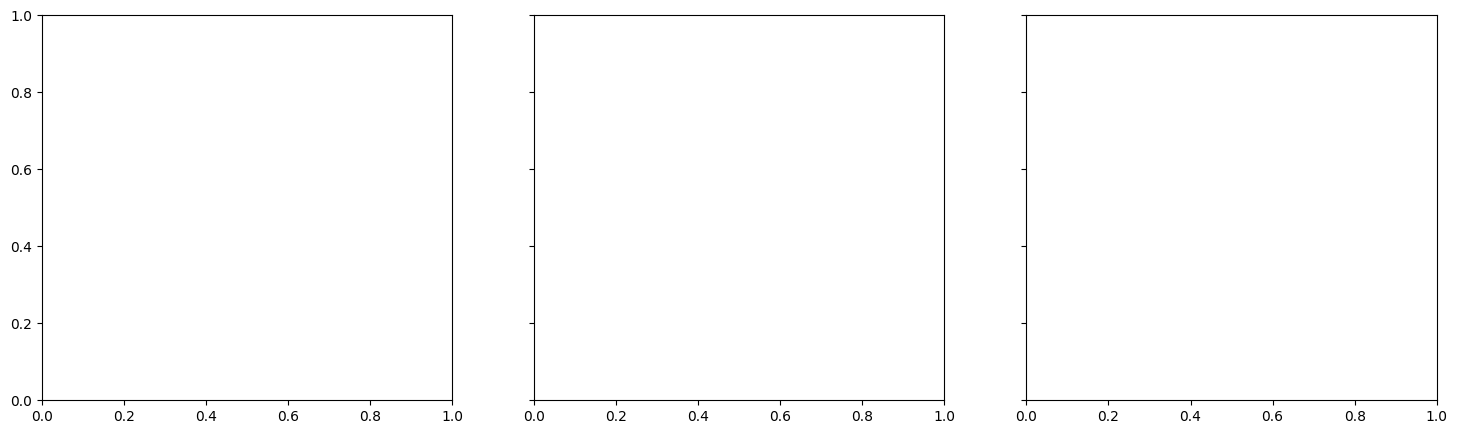

In [79]:
# plotting 

import numpy as np
import matplotlib.pyplot as plt

# Define x-axis from 1990 to 2023
x = np.arange(1990, 2024)

# Define labels for each pair of lines
labels = ['CHN Male', 'CHN Female', 
          'IND Male', 'IND Female', 
          'MAL Male', 'MAL Female']

# Create a figure and subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)  # Share y-axis for better comparison

# Loop through each subplot (3 subplots total)
for i in range(3):
    ax = axes[i]
    male_index = i * 2       # Index for male
    female_index = i * 2 + 1  # Index for female

    # Plot the two lines in each subplot
    ax.plot(x, percentage_mat[male_index], label=labels[male_index], color='blue', linewidth=2)
    ax.plot(x, percentage_mat[female_index], label=labels[female_index], color='red', linewidth=2)

    # Set subplot title
    ax.set_title(f'Subplot {i+1}', fontsize=14)
    ax.set_xlabel('Year')
    if i == 0:
        ax.set_ylabel('No albu percentage %')
    
    # Add legend
    ax.legend()

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
np.sum(age_matrix_vec[i] , axis=0)

array([253023, 259779, 267961, 276418, 284071, 292391, 300324, 308205,
       315918, 324588, 332624, 341431, 350743, 357175, 366297, 375687,
       384929, 392929, 402403, 411495, 420548, 429648, 438267, 447619,
       457360, 466111, 474779, 484076, 493714, 503650, 513136, 521459,
       530033, 539660])

In [ ]:
# calculate total 


## calculate age prevalence 

In [ ]:
pop_2024_vec = []

for matrix in age_matrix_vec:
    # Get second-to-last column and count values not equal to -1
    count = np.sum(matrix[:, -2] != -1)
    pop_2024_vec.append(count)

print(pop_2024_vec)

# obtain one dataframe
# the colums are 18 - 39, 40 - 54, 55-69



## BMI mapping

NumericVector individual_bmi(NumericMatrix& bmitable, int& yearborn, int& index, double& height, 
                             int caloricinterventionyear = 0, double caloricsurplus = 0, int interventionlength = 0,
                             double presentbmi = 0, int startyear = 0)
{
	//Environment global = Environment::global_env();
    NumericVector thisbmitrajectory(121);
    double M1,M2,M3,M4; //hyperparameters
    double y0,y1,y2,y3,b0,b1,b2,d0,d1,d2,m1,m2; //coefficients
    NumericVector rng(4); //rnorm(0,1)
    double thisbmi, thislogbmi, bmicheck, bmioffset = 0; //bmi values for actual, checking, and offset via intervention respectively
    int age;
    bool accept = false;
    
    while(!accept)
    {
        rng = rnorm(4, 0, 1);
        
        //calculate hyperparameters
        M1 = bmitable(index,0) + bmitable(index,6) * rng[0];
        M2 = bmitable(index,1) + bmitable(index,7) * rng[0] + bmitable(index,8) * rng[1];
        M3 = bmitable(index,2) + bmitable(index,9) * rng[0] + bmitable(index,10) * rng[1] + bmitable(index,11) * rng[2];
        M4 = bmitable(index,3) + bmitable(index,12) * rng[0] + bmitable(index,13) * rng[1] + bmitable(index,14) * rng[2] + bmitable(index,15) * rng[3];
        
        //M1 = bmitable(index,0) + bmitable(index,6) * rng[0] + bmitable(index,7) * rng[1] + bmitable(index,8) * rng[2] + bmitable(index,9) * rng[3];
        //M2 = bmitable(index,1) + bmitable(index,10) * rng[0] + bmitable(index,11) * rng[1] + bmitable(index,12) * rng[2];
        //M3 = bmitable(index,2) + bmitable(index,13) * rng[0] + bmitable(index,14) * rng[1];
        //M4 = bmitable(index,3) + bmitable(index,15) * rng[0];
        
        //calculate coefficients
        y0 = M2 + bmitable(index,4) * (yearborn - 1950) + M1 * (35-18);
        y1 = M2 + bmitable(index,4) * (yearborn - 1950);
        y2 = M2 + bmitable(index,4) * (yearborn - 1950) + M3 * (55-35);
        y3 = M2 + bmitable(index,4) * (yearborn - 1950) + M3 * (55-35) + M4 * (75-55);
        m1 = 6 * (0.014492754 * ((y2-y1)/20 - (y1-y0)/17) - 0.003623188 * ((y3-y2)/20 - (y2-y1)/20));
        m2 = 6 * (- 0.003623188 * ((y2-y1)/20 - (y1-y0)/17) + 0.013405797 * ((y3-y2)/20 - (y2-y1)/20));
        b0 = (y1-y0)/17 - 17/6 * m1;
        b1 = (y2-y1)/20 - 10 * m1 - 20/6 * (m2-m1);
        b2 = (y3-y2)/20 - 10 * m2 + 20/6 * m2;
        d0 = m1/(6*17);
        d1 = (m2-m1)/(6*20);
        d2 = (-m2)/(6*20);
        accept = true;
        
        //check plausibility of coefficients for age 80 and above
        age = 80; //85 in the original version_DM
        bmicheck = y2 + b2 * (age-55) + m2/2 * pow(age-55,2) + d2 * pow(age-55,3);
        if ((bmicheck > 4.2)||(bmicheck < 2.6)) accept = false; 	  	
        if ((y0 > 4.2)||(y0 < 2.6)) accept = false; 
        if ((y1 > 4.2)||(y1 < 2.6)) accept = false; 
        if ((y2 > 4.2)||(y2 < 2.6)) accept = false; 
        if ((y3 > 4.2)||(y3 < 2.6)) accept = false;
    }
    
    //simulate bmi trajectories starting from age 18
	if(presentbmi == 0)
	{
		age = 0;
		while(age <= 120)
		{
			if(age > 80) {thisbmi = y2 + b2 * (80-55) + d2 * pow(80-55,3) + m2/2*pow(80-55,2);}
			if(age <= 80) {thisbmi = y2 + b2 * (age-55) + d2 * pow(age-55,3) + m2/2*pow(age-55,2);}
			if(age < 55) {thisbmi = y1 + b1 * (age-35) + d1 * pow(age-35,3) + m1/2*pow(age-35,2);}
			if(age < 35) {thisbmi = y0 + b0 * (age-18) + d0 * pow(age-18,3);}
			//if(age < 18) {thisbmi = y0 + b0 * (18-18) + d0 * pow(18-18,3);}
			
			//save to the large matrix
			thisbmitrajectory[age] = exp(rnorm(1, thisbmi, bmitable(index,5))[0]);

            
			
			//include the effects of caloric intervention at a given year for a given caloric deficit
			if(age + yearborn > caloricinterventionyear)
			{
				int gender = index % 2;
                //double weight = thisbmitrajectory[age]*height*height/10000;
                // give the height in meters
                //double height_in_meters = height/100;
                //deltaweight = caloricintervention(gender, age, height_in_meters, weight, caloricsurplus);
                //thisbmitrajectory[age] = (weight+deltaweight)/(height*height/10000);
				bmioffset = caloric_intervention(thisbmitrajectory[age], height, age, gender, caloricsurplus, interventionlength);
			}
			thisbmitrajectory[age] += bmioffset;
			age++;
		}
	}
	
    return(thisbmitrajectory);
----
based on the above code; write me a function
with age, yearborn, index as input, and BMI as output, 
also, you can calculate the values to avoid duplicate computation

In [84]:
import numpy as np

# Assuming bmitable.csv is in the current directory
file_path = '../data/bmitable.csv'

# Load the CSV file into a numpy array
bmitable = np.genfromtxt(file_path, delimiter=',', skip_header=1)

# Display the shape of the array (optional)
print("Shape of bmitable:", bmitable.shape)

Shape of bmitable: (8, 16)


In [85]:
bmitable

array([[-7.00901000e-03,  3.12015403e+00,  2.65963000e-03,
         3.53190000e-04,  2.52950000e-03,  3.92373500e-02,
         9.19531400e-03, -3.81568900e-02,  1.47991474e-01,
         9.48612000e-04, -2.72257100e-03,  5.87582000e-03,
         2.35523000e-04, -1.29887100e-03, -2.95633000e-04,
         4.54529100e-03],
       [-5.61751000e-03,  3.10342920e+00,  2.24805000e-03,
         6.72300000e-04, -1.09801000e-03,  3.77691300e-02,
         9.01291100e-03, -3.87866710e-02,  1.47129523e-01,
         6.36741000e-04, -2.08374900e-03,  6.18628600e-03,
         1.23000000e-05, -1.05389300e-03, -5.95156000e-04,
         5.29261000e-03],
       [-1.01555100e-02,  3.17483007e+00,  2.57788000e-03,
        -9.69380000e-04,  3.31480000e-03,  2.95149800e-02,
         1.08873390e-02, -2.57781100e-02,  1.82295862e-01,
         6.82810000e-04, -4.53340900e-03,  8.03952700e-03,
        -1.14000000e-05, -9.85763000e-04, -6.79749000e-04,
         6.81356300e-03],
       [-8.17905000e-03,  3.20409465e

In [87]:
bmitable[7,1]

np.float64(3.09792727)

In [ ]:
# index is from 0 to 7 

In [ ]:
import numpy as np
from scipy.stats import norm

def calculate_bmi(age, yearborn, index, bmitable, height=170.0):
    """
    Calculate BMI based on age, year of birth, index, and a BMI table.

    Parameters:
        age (int): The age of the individual.
        yearborn (int): The year the individual was born.
        index (int): The index used to access specific rows in the bmitable.
        bmitable (numpy.ndarray): A 2D array containing the necessary coefficients and hyperparameters.
        height (float): The height of the individual in centimeters (default is 170 cm).

    Returns:
        float: The calculated BMI value.
    """
    # Generate random numbers from a normal distribution
    rng = norm.rvs(loc=0, scale=1, size=4)

    # Calculate hyperparameters
    M1 = bmitable[index, 0] + bmitable[index, 6] * rng[0]
    M2 = bmitable[index, 1] + bmitable[index, 7] * rng[0] + bmitable[index, 8] * rng[1]
    M3 = bmitable[index, 2] + bmitable[index, 9] * rng[0] + bmitable[index, 10] * rng[1] + bmitable[index, 11] * rng[2]
    M4 = bmitable[index, 3] + bmitable[index, 12] * rng[0] + bmitable[index, 13] * rng[1] + bmitable[index, 14] * rng[2] + bmitable[index, 15] * rng[3]

    # Calculate coefficients
    y0 = M2 + bmitable[index, 4] * (yearborn - 1950) + M1 * (35 - 18)
    y1 = M2 + bmitable[index, 4] * (yearborn - 1950)
    y2 = M2 + bmitable[index, 4] * (yearborn - 1950) + M3 * (55 - 35)
    y3 = M2 + bmitable[index, 4] * (yearborn - 1950) + M3 * (55 - 35) + M4 * (75 - 55)
    m1 = 6 * (0.014492754 * ((y2 - y1) / 20 - (y1 - y0) / 17) - 0.003623188 * ((y3 - y2) / 20 - (y2 - y1) / 20))
    m2 = 6 * (-0.003623188 * ((y2 - y1) / 20 - (y1 - y0) / 17) + 0.013405797 * ((y3 - y2) / 20 - (y2 - y1) / 20))
    b0 = (y1 - y0) / 17 - 17 / 6 * m1
    b1 = (y2 - y1) / 20 - 10 * m1 - 20 / 6 * (m2 - m1)
    b2 = (y3 - y2) / 20 - 10 * m2 + 20 / 6 * m2
    d0 = m1 / (6 * 17)
    d1 = (m2 - m1) / (6 * 20)
    d2 = (-m2) / (6 * 20)

    # Calculate BMI based on age
    if age > 80:
        thisbmi = y2 + b2 * (80 - 55) + d2 * np.power(80 - 55, 3) + m2 / 2 * np.power(80 - 55, 2)
    elif 55 <= age <= 80:
        thisbmi = y2 + b2 * (age - 55) + d2 * np.power(age - 55, 3) + m2 / 2 * np.power(age - 55, 2)
    elif 35 <= age < 55:
        thisbmi = y1 + b1 * (age - 35) + d1 * np.power(age - 35, 3) + m1 / 2 * np.power(age - 35, 2)
    elif age < 35:
        thisbmi = y0 + b0 * (age - 18) + d0 * np.power(age - 18, 3)
    elif age < 0:
        thisbmi = -1
    # Apply random noise to the BMI value
    thisbmi = np.exp(norm.rvs(loc=thisbmi, scale=bmitable[index, 5], size=1)[0])

    return thisbmi

In [7]:
import numpy as np
from scipy.stats import norm



def calculate_bmi(ages, yearborn, index, bmitable, height=170.0):
    """
    Calculate BMI based on age, year of birth, index, and a BMI table.

    Parameters:
        age (int): The age of the individual.
        yearborn (int): The year the individual was born.
        index (int): The index used to access specific rows in the bmitable.
        bmitable (numpy.ndarray): A 2D array containing the necessary coefficients and hyperparameters.
        height (float): The height of the individual in centimeters (default is 170 cm).

    Returns:
        float: The calculated BMI value.
    """
    # Generate random numbers from a normal distribution
    rng = norm.rvs(loc=0, scale=1, size=4)

    # Calculate hyperparameters
    M1 = bmitable[index, 0] + bmitable[index, 6] * rng[0]
    M2 = bmitable[index, 1] + bmitable[index, 7] * rng[0] + bmitable[index, 8] * rng[1]
    M3 = bmitable[index, 2] + bmitable[index, 9] * rng[0] + bmitable[index, 10] * rng[1] + bmitable[index, 11] * rng[2]
    M4 = bmitable[index, 3] + bmitable[index, 12] * rng[0] + bmitable[index, 13] * rng[1] + bmitable[index, 14] * rng[2] + bmitable[index, 15] * rng[3]

    # Calculate coefficients
    y0 = M2 + bmitable[index, 4] * (yearborn - 1950) + M1 * (35 - 18)
    y1 = M2 + bmitable[index, 4] * (yearborn - 1950)
    y2 = M2 + bmitable[index, 4] * (yearborn - 1950) + M3 * (55 - 35)
    y3 = M2 + bmitable[index, 4] * (yearborn - 1950) + M3 * (55 - 35) + M4 * (75 - 55)
    m1 = 6 * (0.014492754 * ((y2 - y1) / 20 - (y1 - y0) / 17) - 0.003623188 * ((y3 - y2) / 20 - (y2 - y1) / 20))
    m2 = 6 * (-0.003623188 * ((y2 - y1) / 20 - (y1 - y0) / 17) + 0.013405797 * ((y3 - y2) / 20 - (y2 - y1) / 20))
    b0 = (y1 - y0) / 17 - 17 / 6 * m1
    b1 = (y2 - y1) / 20 - 10 * m1 - 20 / 6 * (m2 - m1)
    b2 = (y3 - y2) / 20 - 10 * m2 + 20 / 6 * m2
    d0 = m1 / (6 * 17)
    d1 = (m2 - m1) / (6 * 20)
    d2 = (-m2) / (6 * 20)

    # Calculate BMI based on age
    # Define conditions
    cond1 = ages > 80
    cond2 = (ages >= 55) & (ages <= 80)
    cond3 = (ages >= 35) & (ages < 55)
    cond4 = (ages >= 0) & (ages < 35)
    cond6 = ages == -1

    # Define corresponding calculations for each condition
    bmi_values = np.select(
        [cond1, cond2, cond3, cond4],# cond6
        [
            0,  # Condition: age > 80
            y2 + b2 * (ages - 55) + d2 * np.power(ages - 55, 3) + m2 / 2 * np.power(ages - 55, 2),
            y1 + b1 * (ages - 35) + d1 * np.power(ages - 35, 3) + m1 / 2 * np.power(ages - 35, 2),
            y0 + b0 * (ages - 18) + d0 * np.power(ages - 18, 3),
            # y0 + b0 * (18 - 18) + d0 * np.power(18 - 18, 3),
            # -1  # Condition: age == -1
        ],
        default=np.nan  # Optional: handle unexpected cases with NaN
    )

    # Apply random noise to the BMI value
    #thisbmi = np.exp(norm.rvs(loc=thisbmi, scale=bmitable[index, 5], size=1)[0])
    scales = bmitable[index, 5]  # Get scale values for the corresponding row

    # Generate random samples from normal distribution and apply exponential transformation
   # bmi_transformed = np.exp(norm.rvs(loc=bmi_values, scale=scales, size=bmi_values.shape))
    bmi_transformed = np.where(ages == -1, -1, np.exp(norm.rvs(loc=bmi_values, scale=scales, size=bmi_values.shape)))

    return bmi_transformed

In [585]:
arr = np.arange(30, 41)  # Includes 30 to 40 (41 is exclusive)
arr = np.insert(arr, 0, [-1, -1, -1])
print(calculate_bmi(arr, 1990, 0, bmitable, height=170.0))

[-1.         -1.         -1.         26.98371902 24.21337479 25.63416359
 25.31326551 27.58133138 26.13782306 25.45926934 25.76050947 27.66925227
 29.17329255 27.51858742]


In [ ]:
matrix = age_matrix_vec[idx]

In [342]:
age_matrix_vec[idx]

array([[ 0,  1,  2, ..., 31, 32, 33],
       [ 0,  1,  2, ..., 31, 32, 33],
       [ 0,  1,  2, ..., 31, 32, 33],
       ...,
       [-1, -1, -1, ..., -1, -1, 50],
       [-1, -1, -1, ..., -1, -1, 50],
       [-1, -1, -1, ..., -1, -1, 50]], shape=(88698, 34))

In [343]:
row = age_matrix_vec[idx][-1]

In [344]:
row

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 50])

In [350]:

first_nonzero_idx = np.where(row != -1)[0] if np.any(row) else 0
first_nonzero_idx

array([33])

In [351]:
first_nonzero_idx

array([33])

In [354]:
row[first_nonzero_idx]

array([50])

In [356]:
1989 + first_nonzero_idx - row[first_nonzero_idx]

array([1972])

In [361]:
# Find rows where all elements are negative
negative_rows = np.all(matrix < 0, axis=1)



In [363]:
rows_with_all_negative = np.where(negative_rows)[0]

In [643]:
for idx in range(8):
    matrix = age_matrix_vec[idx]  # Extract the matrix
    # Check each row, and keep it if not all values are negative
    filtered_matrix = matrix[~np.all(matrix < 0, axis=1)]
    age_matrix_vec[idx] = filtered_matrix

In [6]:
import numpy as np

def apply_bmi(row, idx):
    """Compute BMI using calculate_bmi, with yearborn based on the first nonzero index."""
    first_nonzero_idx = np.where(row >= 0)[0][0] # Find first nonnegative index
    first_nonzero_value = row[first_nonzero_idx]
    yearborn = 1989 + first_nonzero_idx - first_nonzero_value
    
    bmi_values = calculate_bmi(row, yearborn, idx, bmitable) 
    print(f"Shape of returned BMI values: {bmi_values.shape}") 
    print(f"year: {yearborn}")
    return calculate_bmi(row, yearborn, idx, bmitable)  # Use idx instead of 0

# Initialize bmi_matrix
 
bmi_matrix_ls = [] 
# Iterate over age_matrix_vec
for idx in range(8):
    matrix = age_matrix_vec[idx]  # Extract the matrix
    bmi_matrix = np.zeros_like(matrix, dtype=float)
    temp = np.apply_along_axis(lambda row: apply_bmi(row, idx), 1, matrix)  # Apply function row-wise
    bmi_matrix = temp
    bmi_matrix_ls.append(bmi_matrix)


NameError: name 'calculate_bmi' is not defined

In [679]:
bmi_matrix_ls[0].shape

(88417, 34)

In [ ]:
# Create a parent directory if it doesn't exist

parent_dir = "../data/bmi_matrix"
os.makedirs(parent_dir, exist_ok=True)

In [3]:
import numpy as np
import os

In [ ]:

## save 

# Save each matrix as an .npy file
for idx, matrix in enumerate(bmi_matrix_ls):
    file_path = os.path.join(parent_dir, f"bmi_matrix_{idx}.npy")
    np.save(file_path, matrix)
    print(f"Saved: {file_path}")


Saved: ../data/bmi_matrix/bmi_matrix_0.npy
Saved: ../data/bmi_matrix/bmi_matrix_1.npy
Saved: ../data/bmi_matrix/bmi_matrix_2.npy
Saved: ../data/bmi_matrix/bmi_matrix_3.npy
Saved: ../data/bmi_matrix/bmi_matrix_4.npy
Saved: ../data/bmi_matrix/bmi_matrix_5.npy
Saved: ../data/bmi_matrix/bmi_matrix_6.npy
Saved: ../data/bmi_matrix/bmi_matrix_7.npy


## bmi modelling here


In [8]:
# Suppose you know there are N matrices saved
N = 8  # Replace 8 with the actual number
parent_dir = "../data/bmi_matrix" 
bmi_matrix_ls = []
for idx in range(N):
    file_path = os.path.join(parent_dir, f"bmi_matrix_{idx}.npy")
    matrix = np.load(file_path)
    bmi_matrix_ls.append(matrix)

## diabetes prevalence mapping 

In [314]:
# Assuming diabetes_mat_list is a list of numpy arrays
index_of_0_5 = np.where(diabetes_mat_list[0] == 0.5)
print(index_of_0_5)

(array([], dtype=int64), array([], dtype=int64))


## pre diabetes final version


In [454]:
import numpy as np

def schedule_pre_diabetes_probability(age, index, bmi, theta=None):
    beta = 0.2
    if theta is None:
        theta = np.array([-10.73568597 * 1.01, -11.11297803* 0.98, -10.594319 * 1.02, -10.97161203 * 1.02, -10.15266278 * 1.0, -10.52995483 * 1.02, -10.73568597, -11.11297803])
        theta = theta 
    if age < 25 and age > 18:
        prediabetesprob = 0.0001
        return prediabetesprob
    if age < 40:
        alpha = 0.045
    elif age < 50:
        alpha = 0.045
    elif age < 60:
        alpha = 0.045
    elif age < 70:
        alpha = 0.045
    else:
        alpha = 0.04
    # Compute the logistic regression probability
    exp_term = np.exp(theta[index] + alpha * age + beta * bmi)
    prediabetesprob = 1 - 1 / (1 + exp_term)
    
    return prediabetesprob 

def schedule_diabetes_probability(age, index, bmi, theta=None):
    beta = 0.18
    if theta is None:
        theta = np.array([-10.73568597 * 1.01, -11.11297803 * 0.98, -10.59431997 * 1.02, -10.971612 * 1.02, -10.15266278 * 1.02, -10.52995483 * 1.05, -10.73568597, -11.11297803* 1.03])
    if age < 25:
        diabetesprob = 0.00015
        return diabetesprob
    if age < 40:
        alpha = 0.045
    elif age < 50:
        alpha = 0.045
    elif age < 60:
        alpha = 0.045
    elif age < 70:
        alpha = 0.045
    else:
        alpha = 0.035
    # Compute the logistic regression probability
    exp_term = np.exp(theta[index] + alpha * age + beta * bmi)
    diabetesprob = 1 - 1 / (1 + exp_term)
    
    return diabetesprob 

def process_diabetes_matrices(age_matrix_vec, bmi_matrix_ls):
    diabetes_mat_list = []
    
    for idx, (age_mat, bmi_mat) in enumerate(zip(age_matrix_vec, bmi_matrix_ls)):
        prediabetes_prob_matrix = np.vectorize(lambda age, bmi: schedule_pre_diabetes_probability(age, idx, bmi))(age_mat, bmi_mat)
        rand_matrix = np.random.rand(*age_mat.shape)
        prediabetes_matrix = (rand_matrix < prediabetes_prob_matrix) * 0.5
        prediabetes_matrix = np.maximum.accumulate(prediabetes_matrix, axis=1)

        diabetes_prob_matrix = np.vectorize(lambda age, bmi: schedule_diabetes_probability(age, idx, bmi))(age_mat, bmi_mat)
        rand_matrix = np.random.rand(*age_mat.shape)
        diabetes_matrix = np.where(rand_matrix < diabetes_prob_matrix, 1, 0.5)

    
        combined_matrix = np.where(prediabetes_matrix == 0.5, diabetes_matrix, prediabetes_matrix)
        combined_matrix = np.maximum.accumulate(combined_matrix, axis=1)
        
        diabetes_mat_list.append(combined_matrix)
    
    return diabetes_mat_list

# def enforce_persistence(status_matrix):
#     """
#     Ensure that once an individual gets diabetes (first occurrence of 1 in a row),
#     all subsequent values in that row remain 1. If pre-diabetes (0.5) occurs before diabetes,
#     it remains 0.5 until diabetes occurs.
#     """
#     for i in range(status_matrix.shape[0]):  # Iterate over rows
#         for j in range(status_matrix.shape[1]):  # Iterate over columns
#             if j > 0:
#                 if status_matrix[i, j-1] == 1:
#                     status_matrix[i, j] = 1
#                 elif status_matrix[i, j-1] == 0.5 and status_matrix[i, j] != 1:
#                     status_matrix[i, j] = 0.5
#     return status_matrix
def enforce_persistence(status_matrix):
    """
    Ensure that once an individual gets diabetes (first occurrence of 1 in a row),
    all subsequent values in that row remain 1.
    If pre-diabetes (0.5) occurs before diabetes, it remains 0.5 until diabetes occurs.
    """
    # Mark cumulative diabetes presence (1 stays once it appears)
    diabetes_mask = np.maximum.accumulate(status_matrix == 1, axis=1)
    
    # Mark cumulative pre-diabetes presence (0.5 stays until diabetes occurs)
    prediabetes_mask = np.maximum.accumulate(status_matrix == 0.5, axis=1) & ~diabetes_mask
    
    # Construct final status matrix
    return diabetes_mask.astype(float) + prediabetes_mask * 0.5





#combined_matrix = enforce_persistence(combined_matrix)
# def process_diabetes_matrices(age_matrix_vec, bmi_matrix_ls):
#     for idx, (age_mat, bmi_mat) in enumerate(zip(age_matrix_vec, bmi_matrix_ls)):
#         # Compute pre-diabetes probability matrix
#         prediabetes_prob_matrix = np.vectorize(lambda age, bmi: schedule_pre_diabetes_probability(age, idx, bmi))(age_mat, bmi_mat)
#         # Compute diabetes probability matrix
#         diabetes_prob_matrix = np.vectorize(lambda age, bmi: schedule_diabetes_probability(age, idx, bmi))(age_mat, bmi_mat)
        
#         # Generate a random matrix of the same shape (each entry is drawn from U(0,1))
#         rand_matrix = np.random.rand(*age_mat.shape)
        
#         # Create a binary outcome matrix: 1 if random number < diabetes probability, else 0
#         binary_matrix = (rand_matrix < diabetes_prob_matrix).astype(int)
        
#         rand_matrix = np.random.rand(*age_mat.shape)
#         # Create a pre-diabetes matrix: 0.5 if random number < pre-diabetes probability, else 0
#         prediabetes_matrix = (rand_matrix < prediabetes_prob_matrix) * 0.5

#         # debug
#         indices = np.where(prediabetes_matrix == 0.5)
#         #print(indices)

#         # Combine both binary and pre-diabetes matrices
#         combined_matrix = np.maximum(binary_matrix, prediabetes_matrix)  # 1 > 0.5 > 0
        
#         # Enforce persistence for both diabetes and pre-diabetes states
#         combined_matrix = enforce_persistence(combined_matrix)
        
#         # Append the matrix to the list
#         diabetes_mat_list.append(combined_matrix)

# Example call with age_matrix_vec and bmi_matrix_ls (assuming they are defined)
diabetes_mat_list = process_diabetes_matrices(age_matrix_vec, bmi_matrix_ls)


In [455]:
diabetes_mat_list[1]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [456]:
total_count = len(filtered_data)

In [457]:
diabetes_mat_list[0]

array([[0. , 0. , 0. , ..., 0. , 0. , 0. ],
       [0. , 0. , 0. , ..., 0. , 0. , 0. ],
       [0. , 0. , 0. , ..., 0. , 0. , 0. ],
       ...,
       [0. , 0. , 0. , ..., 0. , 0. , 0.5],
       [0. , 0. , 0. , ..., 0. , 0. , 0. ],
       [0. , 0. , 0. , ..., 0. , 0. , 0. ]])

In [458]:
indices = np.where(diabetes_mat_list[0][:, -2] == 0.5)
print(indices)

(array([    9,    11,    18, ..., 87464, 87505, 87519]),)


In [459]:
diabetes_mat_list[0]

array([[0. , 0. , 0. , ..., 0. , 0. , 0. ],
       [0. , 0. , 0. , ..., 0. , 0. , 0. ],
       [0. , 0. , 0. , ..., 0. , 0. , 0. ],
       ...,
       [0. , 0. , 0. , ..., 0. , 0. , 0.5],
       [0. , 0. , 0. , ..., 0. , 0. , 0. ],
       [0. , 0. , 0. , ..., 0. , 0. , 0. ]])

In [460]:
# Assuming `last_col_ages` is a 1D array representing the ages corresponding to the rows of `diabetes_mat_list`

pre_diabetes_percentage_list = []

for idx, diabetes_matrix in enumerate(diabetes_mat_list[:5]):
    # Extract the second-to-last column (pre-diabetes status, assuming 0.5 indicates pre-diabetes)
    second_last_column = diabetes_matrix[:, -2]
    last_col_ages = age_matrix_vec[idx][:, -2]

    mask_all = (last_col_ages >= 18) & (last_col_ages <= 74)
    
    # Apply the mask to the second-to-last column and the last_col_ages
    filtered_data = second_last_column[mask_all]

    # Count the total number of individuals in this age group
    total_count = np.sum(mask_all)
    
    # Count the number of pre-diabetes individuals (assuming pre-diabetes is represented by 0.5)
    pre_diabetes_count = np.sum(filtered_data == 0.5)
    
    # Calculate the percentage of pre-diabetes individuals in the filtered group
    pre_diabetes_percentage = (pre_diabetes_count / total_count) * 100 if total_count > 0 else 0
    
    # Append the result to the list
    pre_diabetes_percentage_list.append(pre_diabetes_percentage)

# Output the pre-diabetes percentage for each matrix
print(pre_diabetes_percentage_list)


[24.417080573951434, 19.094701573432317, 25.89534236407497, 23.41314031180401, 30.640342901675545]


In [461]:
# Initialize cumulative counters
total_pre_diabetes_count = 0
total_population_count = 0

for idx, diabetes_matrix in enumerate(diabetes_mat_list):
    # Extract the second-to-last column (pre-diabetes status)
    second_last_column = diabetes_matrix[:, -2]
    last_col_ages = age_matrix_vec[idx][:, -2]

    # Create mask for age range 18-74
    mask_all = (last_col_ages >= 18) & (last_col_ages <= 74)

    # Apply mask to filter relevant data
    filtered_data = second_last_column[mask_all]

    # Update cumulative counts
    total_pre_diabetes_count += np.sum(filtered_data == 0.5)
    total_population_count += np.sum(mask_all)

# Compute final pre-diabetes prevalence
final_pre_diabetes_percentage = (total_pre_diabetes_count / total_population_count) * 100 if total_population_count > 0 else 0

# Output the final prevalence
print(f"Final Pre-Diabetes Prevalence: {final_pre_diabetes_percentage:.2f}%")


Final Pre-Diabetes Prevalence: 22.63%


In [462]:
total_pre_diabetes_count

36416

In [463]:
import numpy as np

# Define age groups
age_groups = [(18, 29), (30, 39), (40, 49), (50, 59), (60, 69), (70, 74)] 

# Initialize matrices for pre-diabetes
prediabetes_total_counts_mat = np.zeros((8, 6))  # Number of people in each age group
prediabetes_counts_mat = np.zeros((8, 6))  # Number of pre-diabetic people in each age group
prediabetes_prevalence_ls = []  # Prevalence for each ethnicity-gender group

# Iterate over each ethnicity-gender group
for idx in range(8):
    last_col_ages = age_matrix_vec[idx][:, -2]  # Last column of age matrix
    last_col_status = diabetes_mat_list[idx][:, -2]  # Last column of status matrix (0, 0.5, 1)

    # Compute overall pre-diabetes prevalence for idx
    mask_all = (last_col_ages >= 18) & (last_col_ages <= 74)
    total_people = np.sum(mask_all)
    prediabetic_people = np.sum((last_col_status[mask_all] == 0.5))  # Count pre-diabetic people
    
    # Store pre-diabetes prevalence (avoid division by zero)
    prediabetes_prevalence_ls.append(prediabetic_people / total_people if total_people > 0 else 0)
    prediabetes_prevalence_ls = prediabetes_prevalence_ls[:6]  # Exclude "others" if necessary

    # Assign people to age groups and count
    for group_idx, (lower, upper) in enumerate(age_groups):
        mask = (last_col_ages >= lower) & (last_col_ages <= upper)
        
        prediabetes_total_counts_mat[idx, group_idx] = np.sum(mask)  # Total people in age group
        prediabetes_counts_mat[idx, group_idx] = np.sum((last_col_status[mask] == 0.5))  # Pre-diabetic people in age group

# Compute age-specific pre-diabetes prevalence
prediabetes_age_specific_prevalence = np.divide(
    prediabetes_counts_mat.sum(axis=0),
    prediabetes_total_counts_mat.sum(axis=0),
    out=np.zeros_like(prediabetes_counts_mat.sum(axis=0)),  # Avoid division by zero
    where=prediabetes_total_counts_mat.sum(axis=0) > 0
)

# Concatenate the final results for pre-diabetes
prediabetes_final_result = np.concatenate([prediabetes_prevalence_ls, prediabetes_age_specific_prevalence])

# Print the final result for pre-diabetes
print("Pre-Diabetes Final Result:")
print(prediabetes_final_result * 100)

Pre-Diabetes Final Result:
[24.41708057 19.09470157 25.89534236 23.41314031 30.6403429  28.40219997
  8.41939091 13.19909061 21.73353081 30.43786448 35.45739974 38.10962901]


In [464]:
import numpy as np

# Define age groups
age_groups = [(18, 29), (30, 39), (40, 49), (50, 59), (60, 69), (70, 74)]

# Initialize matrices for diabetes
diabetes_total_counts_mat = np.zeros((8, 6))  # Number of people in each age group
diabetes_counts_mat = np.zeros((8, 6))  # Number of diabetic people in each age group
diabetes_prevalence_ls = []  # Prevalence for each ethnicity-gender group

# Iterate over each ethnicity-gender group
for idx in range(8):
    last_col_ages = age_matrix_vec[idx][:, -2]  # Last column of age matrix
    last_col_diabetes = diabetes_mat_list[idx][:, -2]  # Last column of diabetes matrix

    # Compute overall diabetes prevalence for idx
    mask_all = (last_col_ages >= 18) & (last_col_ages <= 74)
    total_people = np.sum(mask_all)
    diabetic_people = np.sum(last_col_diabetes[mask_all] == 1)
    
    # Store diabetes prevalence (avoid division by zero)
    diabetes_prevalence_ls.append(diabetic_people / total_people if total_people > 0 else 0)
    
    
    # Assign people to age groups and count
    for group_idx, (lower, upper) in enumerate(age_groups):
        mask = (last_col_ages >= lower) & (last_col_ages <= upper)
        
        diabetes_total_counts_mat[idx, group_idx] = np.sum(mask)  # Total people in age group
        # come to 0 and 1 
        diabetes_counts_mat[idx, group_idx] = np.sum(last_col_diabetes[mask] == 1)  # Diabetic people in age group

# Exclude "others" if necessary
diabetes_prevalence_ls = diabetes_prevalence_ls[:6] 

# Compute age-specific diabetes prevalence
diabetes_age_specific_prevalence = np.divide(
    diabetes_counts_mat.sum(axis=0),
    diabetes_total_counts_mat.sum(axis=0),
    out=np.zeros_like(diabetes_counts_mat.sum(axis=0)),  # Avoid division by zero
    where=diabetes_total_counts_mat.sum(axis=0) > 0
)

# Concatenate the final results for diabetes
diabetes_final_result = np.concatenate([diabetes_prevalence_ls, diabetes_age_specific_prevalence])

# Print the final result for diabetes
print("Diabetes Final Result:")
print(diabetes_final_result * 100)

Diabetes Final Result:
[ 8.55753311  5.72709654 13.26776767 12.26800297 19.13235485 14.68058102
  0.2137736   1.6368951   4.67512396 11.7214937  20.50092764 26.35473114]


In [465]:
targeting_diabeteslist = np.array([ 8.2, 5.8, 13.5, 12.4, 19.1, 14.4, 0.2 , 1.9, 5.0, 10.8, 21.8, 24.2])

In [466]:
targeting_diabeteslist = np.array([ 8.2, 5.8, 13.5, 12.4, 19.1, 14.4, 0.2 , 1.9, 5.0, 10.8, 21.8, 24.2])

In [467]:
parent_dir

'../data/bmi_matrix'

In [468]:

for idx, matrix in enumerate(diabetes_mat_list):
    file_path = os.path.join(parent_dir, f"diabetes_mat_{idx}.npy")
    np.save(file_path, matrix)
    print(f"Saved: {file_path}")

Saved: ../data/bmi_matrix/diabetes_mat_0.npy
Saved: ../data/bmi_matrix/diabetes_mat_1.npy
Saved: ../data/bmi_matrix/diabetes_mat_2.npy
Saved: ../data/bmi_matrix/diabetes_mat_3.npy
Saved: ../data/bmi_matrix/diabetes_mat_4.npy
Saved: ../data/bmi_matrix/diabetes_mat_5.npy
Saved: ../data/bmi_matrix/diabetes_mat_6.npy
Saved: ../data/bmi_matrix/diabetes_mat_7.npy


In [469]:
for idx, matrix in enumerate(hyper_mat_list):
    file_path = os.path.join(parent_dir, f"hyper_mat_{idx}.npy")
    np.save(file_path, matrix)
    print(f"Saved: {file_path}")

NameError: name 'hyper_mat_list' is not defined

In [215]:
diabetes_mat_list[0]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(88417, 34))

In [204]:
age_matrix_vec[0]

array([[ 0,  1,  2, ..., 31, 32, 33],
       [ 0,  1,  2, ..., 31, 32, 33],
       [ 0,  1,  2, ..., 31, 32, 33],
       ...,
       [-1, -1, -1, ..., -1, -1, 50],
       [-1, -1, -1, ..., -1, -1, 50],
       [-1, -1, -1, ..., -1, -1, 50]], shape=(88417, 34))

In [ ]:
import numpy as np

# Define age groups
age_groups = [(18, 29), (30, 39), (40, 49), (50, 59), (60, 69), (70, 74)]

# Initialize matrices for diabetes
diabetes_total_counts_mat = np.zeros((8, 6))  # Number of people in each age group
diabetes_counts_mat = np.zeros((8, 6))  # Number of diabetic people in each age group
diabetes_prevalence_ls = []  # Prevalence for each ethnicity-gender group

# Iterate over each ethnicity-gender group
for idx in range(8):
    last_col_ages = age_matrix_vec[idx][:, -2]  # Last column of age matrix
    last_col_diabetes = diabetes_mat_list[idx][:, -2]  # Last column of diabetes matrix

    # Compute overall diabetes prevalence for idx
    mask_all = (last_col_ages >= 18) & (last_col_ages <= 74)
    total_people = np.sum(mask_all)
    diabetic_people = np.sum(last_col_diabetes[mask_all])
    
    # Store diabetes prevalence (avoid division by zero)
    diabetes_prevalence_ls.append(diabetic_people / total_people if total_people > 0 else 0)
    diabetes_prevalence_ls = diabetes_prevalence_ls[:6]  # Exclude "others" if necessary

    # Assign people to age groups and count
    for group_idx, (lower, upper) in enumerate(age_groups):
        mask = (last_col_ages >= lower) & (last_col_ages <= upper)
        
        diabetes_total_counts_mat[idx, group_idx] = np.sum(mask)  # Total people in age group
        diabetes_counts_mat[idx, group_idx] = np.sum(last_col_diabetes[mask])  # Diabetic people in age group

# Compute age-specific diabetes prevalence
diabetes_age_specific_prevalence = np.divide(
    diabetes_counts_mat.sum(axis=0),
    diabetes_total_counts_mat.sum(axis=0),
    out=np.zeros_like(diabetes_counts_mat.sum(axis=0)),  # Avoid division by zero
    where=diabetes_total_counts_mat.sum(axis=0) > 0
)

# Concatenate the final results for diabetes
diabetes_final_result = np.concatenate([diabetes_prevalence_ls, diabetes_age_specific_prevalence])

# Print the final result for diabetes
print("Diabetes Final Result:")
print(diabetes_final_result * 100)

Diabetes Final Result:
[20.84885486 15.30318957 26.33605493 23.7889755  34.4785037  28.51501904
  4.34618167  8.08704125 15.48554318 27.07735928 38.39196518 45.63359733]


In [ ]:
print(diabetes_final_result * 100)

In [449]:
targeting_diabeteslist = np.array([ 8.2, 5.8, 13.5, 12.4, 19.1, 14.4, 0.2 , 1.9, 5.0, 10.8, 21.8, 24.2])

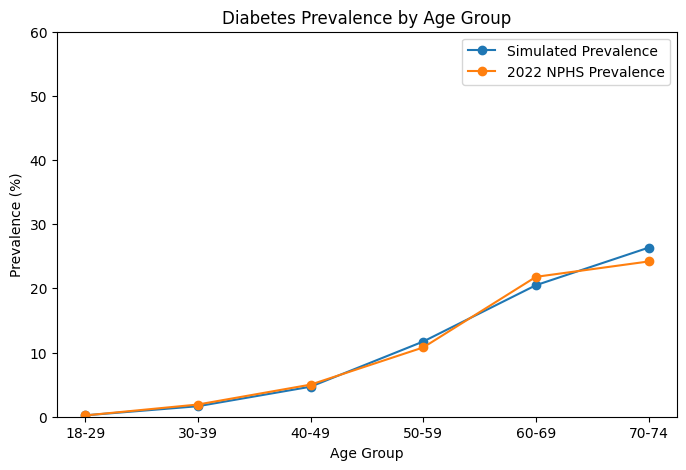

In [470]:
import matplotlib.pyplot as plt
import numpy as np


age_labels = ["18-29", "30-39", "40-49", "50-59", "60-69", "70-74"]


# Extracting relevant slices
simulated_prevalence = diabetes_final_result[6:] * 100
nphs_prevalence = targeting_diabeteslist[6:] 

# Plotting
plt.figure(figsize=(8, 5))

plt.plot(age_labels, simulated_prevalence, marker='o', linestyle='-', label="Simulated Prevalence", markersize=6)
plt.plot(age_labels, nphs_prevalence, marker='o', linestyle='-', label="2022 NPHS Prevalence", markersize=6)
plt.ylim(0,60)
plt.xlabel("Age Group")
plt.ylabel("Prevalence (%)")
plt.title("Diabetes Prevalence by Age Group")
plt.legend()
plt.show()


In [387]:
targeting_diabeteslist

array([ 8.2,  5.8, 13.5, 12.4, 19.1, 14.4,  0.2,  1.9,  5. , 10.8, 21.8,
       24.2])

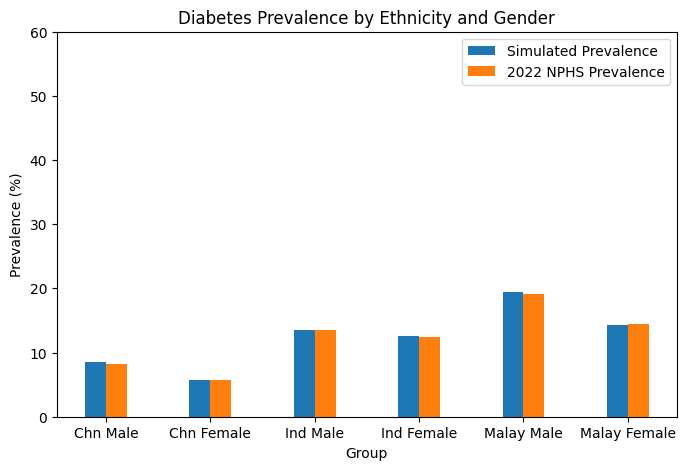

In [ ]:
simulated_prevalence_2 = diabetes_final_result[:6] * 100
nphs_prevalence_2 = targeting_diabeteslist[:6] 
group_labels = ["Chn Male", "Chn Female", "Ind Male", "Ind Female", "Malay Male", "Malay Female"]


width = 0.2  # Bar width
x = np.arange(len(group_labels))

plt.figure(figsize=(8, 5))

plt.bar(x - width/2, simulated_prevalence_2, width, label="Simulated Prevalence")
plt.bar(x + width/2, nphs_prevalence_2, width, label="2022 NPHS Prevalence")
plt.ylim(0,60)
plt.xlabel("Group")
plt.ylabel("Prevalence (%)")
plt.title("Diabetes Prevalence by Ethnicity and Gender")
plt.xticks(x, group_labels)
plt.legend()
plt.show()

## hypertension mapping

In [610]:
# Read the hypertransition probability matrix
hypertransition = pd.read_csv("../data/hypertransistionprob.csv")

In [106]:
import numpy as np

def schedule_hypertension_probability(age, index, bmi,  theta=None):
    """
    Set parameters for each individual based on ethnicity and gender (given by index).
    Logistic regression portion (need to rethink):
    
        alpha = 0.08207898
        beta = 0.10498145
        theta = [-8.210539, -8.380487, -8.030455, -8.065594, -8.352823, -8.645856, -8.071825, -8.254004]
        
        hyperprob = 1 - 1/(1 + exp(theta[index] + alpha * age + beta * bmitrajectory[age]))
    
    In this implementation we assume that bmitrajectory for an individual is given by the variable `bmi`
    and, as requested, we set hyperprob = 0 if age < 10.
    """
    alpha=0.08207898 * 0.9
    beta=0.10498145 
    if theta is None:
        theta = np.array([-8.210539  * 0.92, -8.380487 * 0.95 , -8.030455* 0.95, -8.065594 * 0.99 ,
                          -8.352823 * 0.93, -8.645856 , -8.071825, -8.254004]) * 1.2
    
    if age < 10:
        return 0.0
    if age > 55:
        alpha=0.08207898 * 0.75
        exp_term = np.exp(theta[index] + alpha * age + beta * bmi)
        hyperprob = 1 - 1 / (1 + exp_term)
        return hyperprob
    else:
        # Compute the logistic regression probability
        exp_term = np.exp(theta[index] + alpha * age + beta * bmi)
        hyperprob = 1 - 1 / (1 + exp_term)
        return hyperprob

hyper_mat_list = []

def enforce_persistence(binary_matrix):
    """
    Ensure that once an individual gets hypertension (first occurrence of 1 in a row),
    all subsequent values in that row remain 1.
    """
    for i in range(binary_matrix.shape[0]):  # Iterate over rows
        first_one_idx = np.argmax(binary_matrix[i, :])  # Find the first occurrence of 1
        if binary_matrix[i, first_one_idx] == 1:  # Ensure there is at least one 1 in the row
            binary_matrix[i, first_one_idx:] = 1  # Set all subsequent values to 1
    return binary_matrix

# Loop over each pair of age and BMI matrices (each corresponding to an index/ethnicity-gender group)
for idx, (age_mat, bmi_mat) in enumerate(zip(age_matrix_vec, bmi_matrix_ls)):
    # Use np.vectorize to apply the probability function elementwise.
    # For each entry, the function uses the corresponding age and bmi values along with the current group index.
    vec_prob = np.vectorize(lambda age, bmi: schedule_hypertension_probability(age, idx, bmi))
    
    # Compute the hyperprobability matrix
    hyperprob_matrix = vec_prob(age_mat, bmi_mat)
    
    # Generate a random matrix of the same shape (each entry is drawn from U(0,1))
    rand_matrix = np.random.rand(*age_mat.shape)
    
    # Create a binary outcome matrix: 1 if random number < hyperprobability, else 0.
    binary_matrix = (rand_matrix < hyperprob_matrix).astype(int)
    binary_matrix = enforce_persistence(binary_matrix)
    
    # Append the binary matrix to the list.
    hyper_mat_list.append(binary_matrix)


In [218]:
hyper_mat_list

[array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(88417, 34)),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(91217, 34)),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 1],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(16696, 34)),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(16310, 34)),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
      

In [48]:
N = 8  # Replace 8 with the actual number
parent_dir = "../data/bmi_matrix" 
bmi_matrix_ls_v = []
for idx in range(N):
    file_path = os.path.join(parent_dir, f"bmi_matrix_{idx}.npy")
    matrix = np.load(file_path)
    bmi_matrix_ls_v.append(matrix)

In [102]:
import os
import numpy as np
import pandas as pd

# List to store the NumPy arrays (equivalent to std::vector<ArrayXXi> in C++)
age_matrix_vec = []

# Number of files to read
num_files = 8  # Change this to the actual number of files to read

path = "/Users/haolong/Documents/demos_v_matrix/output/"
for i in range(num_files):
    # Create the filename dynamically

    filename = f"popu_matrix_{i}.csv"
    matrix = pd.read_csv(path + filename).to_numpy() # convert to numpy
    age_matrix_vec.append(matrix)

for idx in range(8):
    matrix = age_matrix_vec[idx]  # Extract the matrix
    # Check each row, and keep it if not all values are negative
    filtered_matrix = matrix[~np.all(matrix < 0, axis=1)]
    age_matrix_vec[idx] = filtered_matrix

In [ ]:
# hypertension mapping

import numpy as np

# Define age groups
age_groups = [(18, 29), (30, 39), (40, 49), (50, 59), (60, 69), (70, 74)]

# Initialize matrices
total_counts_mat = np.zeros((8, 6))  # Number of people in each age group
hypertension_counts_mat = np.zeros((8, 6))  # Number of hypertensive people in each age group
prevalence_ls = []  # Prevalence for each ethnicity-gender group

# Iterate over each ethnicity-gender group
for idx in range(8):
    last_col_ages = age_matrix_vec[idx][:, -2]  # Last column of age matrix
    last_col_hyper = hyper_mat_list[idx][:, -2]  # Last column of hypertension matrix

    # Compute overall prevalence for idx
    mask_all = (last_col_ages >= 18) & (last_col_ages <= 74)
    total_people = np.sum(mask_all)
    hypertensive_people = np.sum(last_col_hyper[mask_all])
    
    # Store prevalence (avoid division by zero)
    prevalence_ls.append(hypertensive_people / total_people if total_people > 0 else 0)
    prevalence_ls = prevalence_ls[:6] # except others
    # Assign people to age groups and count
    for group_idx, (lower, upper) in enumerate(age_groups):
        mask = (last_col_ages >= lower) & (last_col_ages <= upper)
        
        total_counts_mat[idx, group_idx] = np.sum(mask)  # Total people in age group
        hypertension_counts_mat[idx, group_idx] = np.sum(last_col_hyper[mask])  # Hypertensive people in age group

# Compute age-specific prevalence
age_specific_prevalence = np.divide(
    hypertension_counts_mat.sum(axis=0),
    total_counts_mat.sum(axis=0),
    out=np.zeros_like(hypertension_counts_mat.sum(axis=0)),  # Avoid division by zero
    where=total_counts_mat.sum(axis=0) > 0
)

# Concatenate the final results
final_result = np.concatenate([prevalence_ls, age_specific_prevalence])

# Print the final result
print(final_result)


[0.44370861 0.29730973 0.42633142 0.36572012 0.38485518 0.20871527
 0.0562389  0.13949334 0.30008371 0.52511519 0.67450407 0.77407253]


In [544]:
final_result

array([0.44370861, 0.29730973, 0.42633142, 0.36572012, 0.38485518,
       0.20871527, 0.0562389 , 0.13949334, 0.30008371, 0.52511519,
       0.67450407, 0.77407253])

[0.44370861 0.29730973 0.42633142 0.36572012 0.38485518 0.20871527
 0.0562389  0.13949334 0.30008371 0.52511519 0.67450407 0.77407253]


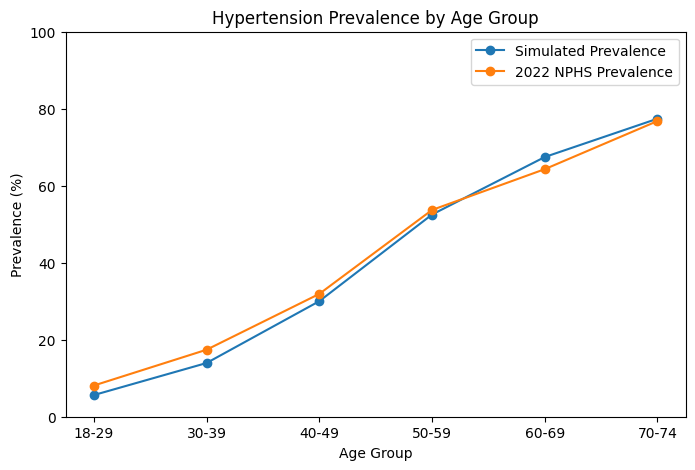

In [546]:
import matplotlib.pyplot as plt
import numpy as np


age_labels = ["18-29", "30-39", "40-49", "50-59", "60-69", "70-74"]

final_result = np.concatenate([prevalence_ls, age_specific_prevalence])

# Print the final result
print(final_result)

# Extracting relevant slices
simulated_prevalence = final_result[6:] * 100
nphs_prevalence = targeting_list[6:] * 100

# Plotting
plt.figure(figsize=(8, 5))

plt.plot(age_labels, simulated_prevalence, marker='o', linestyle='-', label="Simulated Prevalence", markersize=6)
plt.plot(age_labels, nphs_prevalence, marker='o', linestyle='-', label="2022 NPHS Prevalence", markersize=6)
plt.ylim(0,100)
plt.xlabel("Age Group")
plt.ylabel("Prevalence (%)")
plt.title("Hypertension Prevalence by Age Group")
plt.legend()
plt.show()


In [112]:
import numpy as np

targeting_list = np.array([44.6, 30.3, 44.1, 37, 39.6, 21.8, 8.1, 17.4, 31.9, 53.7, 64.3, 76.8]) / 100
print(targeting_list)


[0.446 0.303 0.441 0.37  0.396 0.218 0.081 0.174 0.319 0.537 0.643 0.768]


[0.44636619 0.29763238 0.43205896 0.37051022 0.39086035 0.21214198
 0.05598694 0.13773573 0.29607549 0.52461015 0.67943    0.77544701]


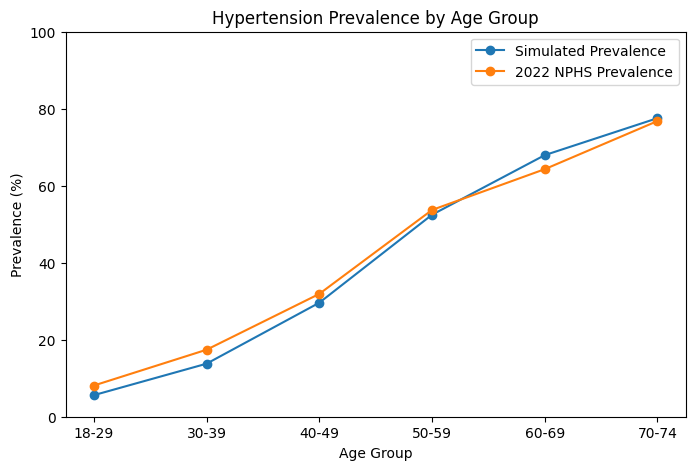

In [117]:
import matplotlib.pyplot as plt
import numpy as np


age_labels = ["18-29", "30-39", "40-49", "50-59", "60-69", "70-74"]

final_result = np.concatenate([prevalence_ls, age_specific_prevalence])

# Print the final result
print(final_result)

# Extracting relevant slices
simulated_prevalence = final_result[6:] * 100
nphs_prevalence = targeting_list[6:] * 100

# Plotting
plt.figure(figsize=(8, 5))

plt.plot(age_labels, simulated_prevalence, marker='o', linestyle='-', label="Simulated Prevalence", markersize=6)
plt.plot(age_labels, nphs_prevalence, marker='o', linestyle='-', label="2022 NPHS Prevalence", markersize=6)
plt.ylim(0,100)
plt.xlabel("Age Group")
plt.ylabel("Prevalence (%)")
plt.title("Hypertension Prevalence by Age Group")
plt.legend()
plt.show()


In [ ]:
final_result[:6]
targeting_list[:6]

I want to have grouped bar chart; final_result[idx] and targeting_list[idx] for one group
6 groups totally, name as chn male, chn female, ind male,..., malay male, malay female

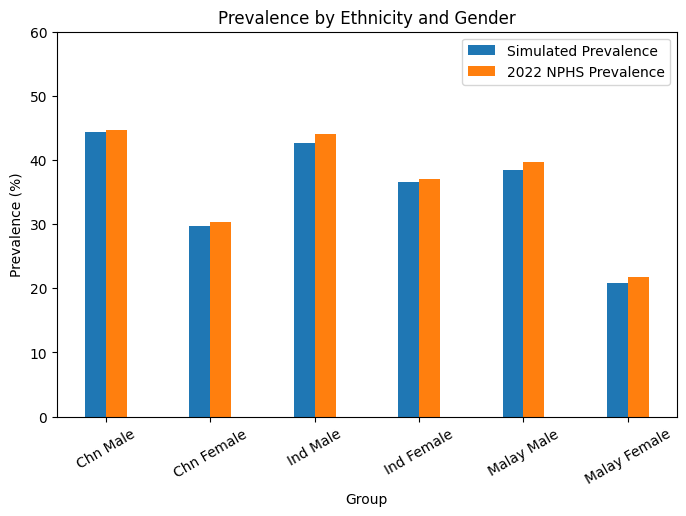

In [210]:
import matplotlib.pyplot as plt
import numpy as np

# Example data (replace with your actual lists)
group_labels = ["Chn Male", "Chn Female", "Ind Male", "Ind Female", "Malay Male", "Malay Female"]

# Extracting relevant slices
simulated_prevalence_2 = final_result[:6] * 100
nphs_prevalence_2 = targeting_list[:6] * 100

x = np.arange(len(group_labels))
width = 0.2  # Bar width

plt.figure(figsize=(8, 5))

plt.bar(x - width/2, simulated_prevalence_2, width, label="Simulated Prevalence")
plt.bar(x + width/2, nphs_prevalence_2, width, label="2022 NPHS Prevalence")
plt.ylim(0,60)
plt.xlabel("Group")
plt.ylabel("Prevalence (%)")
plt.title("Prevalence by Ethnicity and Gender")
plt.xticks(x, group_labels, rotation=30)
plt.legend()
plt.show()


# do a report...

In [ ]:
# prevalence_ls = []
# for idx in range(6):
#     last_col_ages = age_matrix_vec[idx][:, -1]  # Last column of age matrix
#     last_col_hyper = hyper_mat_list[idx][:, -1]  # Last column of hypertension matrix

#     # Filter individuals within the target age range (18-74)
#     mask = (last_col_ages >= 18) & (last_col_ages <= 74)
    
#     total_people = np.sum(mask)  # Total people in this index group
#     hypertensive_people = np.sum(last_col_hyper[mask])  # Hypertensive people in this index group
    
#     # Calculate prevalence (avoid division by zero)
#     prevalence = hypertensive_people / total_people if total_people > 0 else 0
#     prevalence_ls.append(prevalence)


# print(prevalence_ls)
# target_prevalence_ls = [44.6,30.3,44.1,37,39.6,21.8]



[np.float64(0.6632303582437153), np.float64(0.5900881164500268), np.float64(0.6725932749884845), np.float64(0.6585927426782097), np.float64(0.6419453663517999), np.float64(0.5731122379059888)]


In [ ]:
# import numpy as np

# # Define age groups
# age_groups = [(18,29),(30,39), (40, 49), (50, 59),(60,69),(70, 74)]

# # Initialize two 8 × 4 matrices
# total_counts_mat = np.zeros((8, 6))  # Stores the number of people in each age group
# hypertension_counts_mat = np.zeros((8, 6))  # Stores the number of people with hypertension in each age group

# # Iterate over each ethnicity-gender group (idx)
# for idx in range(8):
#     last_col_ages = age_matrix_vec[idx][:, -1]  # Last column of age matrix
#     last_col_hyper = hyper_mat_list[idx][:, -1]  # Last column of hypertension matrix

#     # Assign people to age groups and count
#     for group_idx, (lower, upper) in enumerate(age_groups):
#         mask = (last_col_ages >= lower) & (last_col_ages <= upper)
        
#         total_counts_mat[idx, group_idx] = np.sum(mask)  # Total people in age group
#         hypertension_counts_mat[idx, group_idx] = np.sum(last_col_hyper[mask])  # Hypertensive people in age group



# hypertension_counts_mat.sum(axis=0) / total_counts_mat.sum(axis=0) # age specfic 

# targeting_list = [44.6,30.3,44.1,37,39.6,21.8,8.1,17.4,31.9,53.7,64.3,76.8]/100
# # targeting 


array([0.09614423, 0.34685483, 0.67507253, 0.9209074 , 0.99254407,
       0.99970033])

In [636]:
!pip3 install torch torchvision torchaudio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 MB 11.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 11.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 9.0 MB/s eta 0:00:00


In [691]:
import torch
import torch.nn as nn
import torch.optim as optim

# Assuming age_groups is defined as a list of tuples for age ranges
age_groups = [(18, 29), (30, 39), (40, 49), (50, 59), (60, 69), (70, 74)]  # Example definition

# Assuming age_matrix_vec and bmi_matrix_ls are predefined tensors
# Example placeholders (user must replace with actual data)
# age_matrix_vec = [torch.randn(100, 10) * 50 + 25 for _ in range(8)]  # 8 batches, 100 samples, 10 time steps
# bmi_matrix_ls = [torch.randn(100, 10) * 5 + 25 for _ in range(8)]

# Define enforce_persistence function (example implementation)
def enforce_persistence(binary_matrix):
    # Example: Ensure once hypertensive, remains hypertensive in subsequent time steps
    for t in range(1, binary_matrix.shape[1]):
        binary_matrix[:, t] = torch.maximum(binary_matrix[:, t], binary_matrix[:, t-1])
    return binary_matrix

# Convert data to PyTorch tensors
targeting_list = torch.tensor([44.6, 30.3, 44.1, 37, 39.6, 21.8, 8.1, 17.4, 31.9, 53.7, 64.3, 76.8]) / 100

def hypertension_model(alpha, beta, theta):
    hyper_mat_list = []
    for idx in range(8):  # Assuming 8 matrices as per age_matrix_vec
        age_mat  = torch.tensor(age_matrix_vec[idx], dtype=torch.float32)
        bmi_mat = torch.tensor(bmi_matrix_ls[idx], dtype=torch.float32)
        
        # Vectorized computation without torch.vectorize
        hyperprob_matrix = 1 - 1 / (1 + torch.exp(theta[idx] + alpha * age_mat + beta * bmi_mat))
        # hyperprob_matrix_np = hyperprob_matrix.detach().numpy()
        # Replace stochastic sampling with expected values for differentiability
        # If sampling is necessary, consider using Gumbel-Softmax for differentiable sampling
        # For deterministic approach, use probabilities directly
        binary_matrix = hyperprob_matrix  # Using probabilities instead of sampled binaries
        
        binary_matrix = enforce_persistence(binary_matrix)
        hyper_mat_list.append(binary_matrix)
    
    total_counts_mat = torch.zeros((8, 6))
    hypertension_counts_mat = torch.zeros((8, 6))
    prevalence_ls = []
    
    for idx in range(8):
        last_col_ages = torch.tensor(age_matrix_vec[idx][:, -1], dtype=torch.float32) 
        last_col_hyper = torch.tensor(hyper_mat_list[idx][:, -1], dtype=torch.float32) 
        mask_all = (last_col_ages >= 18) & (last_col_ages <= 74)
        total_people = torch.sum(mask_all)
        hypertensive_people = torch.sum(last_col_hyper[mask_all])  # Sum of probabilities
        prevalence_ls.append(hypertensive_people / total_people)
        
        for group_idx, (lower, upper) in enumerate(age_groups):
            mask = (last_col_ages >= lower) & (last_col_ages <= upper)
            total_counts_mat[idx, group_idx] = torch.sum(mask)
            hypertension_counts_mat[idx, group_idx] = torch.sum(last_col_hyper[mask])
    
    #prevalence_ls = prevalence_ls[:6]
    prevalence_tensor = torch.tensor(prevalence_ls, dtype=torch.float32)
    prevalence_tensor_sliced = prevalence_tensor[:6].clone()

    hypertension_sum = hypertension_counts_mat.sum(dim=0)
    total_sum = total_counts_mat.sum(dim=0)
    age_specific_prevalence = torch.zeros_like(hypertension_sum)
    age_specific_prevalence = torch.div(hypertension_sum,total_sum)
    # age_specific_prevalence = torch.div(
    #     hypertension_counts_mat.sum(dim=0),
    #     total_counts_mat.sum(dim=0),
    #     out=torch.zeros_like(hypertension_counts_mat.sum(dim=0)),
        
    #     rounding_mode=None
    # )
    
    # Ensure output matches targeting_list size (8 + 6 = 14 vs 12 target)
    # Adjust to select first 8 + 4 = 12 elements or correct age_groups definition
    # Assuming age_groups should have 4 groups to make 8 + 4 = 12:
    # age_groups = [(18-29), (30-39), (40-49), (50-74)] (example adjustment)
    # For this example, we'll slice to match (temporary fix)
    final_result = torch.cat([torch.tensor(prevalence_tensor_sliced), age_specific_prevalence])
    return final_result

# Initialize parameters
alpha = torch.tensor(0.08207898, requires_grad=True)
beta = torch.tensor(0.10498145, requires_grad=True)
theta = torch.tensor([-8.210539, -8.380487, -8.030455, -8.065594, -8.352823, -8.645856, -8.071825, -8.254004], requires_grad=True)

# Define optimizer
optimizer = optim.Adam([alpha, beta, theta], lr=0.01)

# Training loop
for epoch in range(100):  # Increased number of epochs
    optimizer.zero_grad()
    predictions = hypertension_model(alpha, beta, theta)
    loss = torch.mean((predictions - targeting_list) ** 2)
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

print(f"Optimized Parameters: alpha={alpha.item()}, beta={beta.item()}, theta={theta.detach().numpy()}")

/var/folders/01/x6yqm8xj77jcsrwqqry44fc40000gq/T/ipykernel_94859/2222867216.py:46: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  last_col_hyper = torch.tensor(hyper_mat_list[idx][:, -1], dtype=torch.float32)
/var/folders/01/x6yqm8xj77jcsrwqqry44fc40000gq/T/ipykernel_94859/2222867216.py:78: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  final_result = torch.cat([torch.tensor(prevalence_tensor_sliced), age_specific_prevalence])


RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim

# Assuming age_groups is defined as a list of tuples for age ranges
age_groups = [(18, 29), (30, 39), (40, 49), (50, 59), (60, 69), (70, 74)]

# Convert data to PyTorch tensors (ensure they're normalized)
age_matrix_vec = [torch.tensor(matrix, dtype=torch.float32) for matrix in age_matrix_vec]
bmi_matrix_ls = [torch.tensor(matrix, dtype=torch.float32) for matrix in bmi_matrix_ls]

# Differentiable approximation for enforce_persistence
def enforce_persistence(binary_matrix, temperature=0.1):
    new_matrix = binary_matrix.clone()
    for t in range(1, binary_matrix.shape[1]):
        # Use a softmax-based smooth maximum approximation
        prev = new_matrix[:, t-1]
        curr = binary_matrix[:, t]
        new_matrix[:, t] = (prev * torch.sigmoid((prev - curr)/temperature) + 
                            curr * torch.sigmoid((curr - prev)/temperature))
    return new_matrix

def hypertension_model(alpha, beta, theta):
    hyper_mat_list = []
    for idx in range(8):
        # No need to clone/detach here if age_matrix_vec and bmi_matrix_ls are fixed tensors
        age_mat = age_matrix_vec[idx]
        bmi_mat = bmi_matrix_ls[idx]
        
        # Compute probabilities
        hyperprob_matrix = torch.sigmoid(theta[idx] + alpha * age_mat + beta * bmi_mat)
        binary_matrix = enforce_persistence(hyperprob_matrix)
        hyper_mat_list.append(binary_matrix)
    
    # [Rest of the function remains the same...]

# Initialize parameters with better values
alpha = torch.nn.Parameter(torch.tensor(0.1))  # Use nn.Parameter for clarity
beta = torch.nn.Parameter(torch.tensor(0.1))
theta = torch.nn.Parameter(torch.zeros(8))  # Initialize theta to zeros

optimizer = optim.Adam([alpha, beta, theta], lr=0.1)  # Increased learning rate

# Training loop with gradient monitoring
for epoch in range(1000):
    optimizer.zero_grad()
    predictions = hypertension_model(alpha, beta, theta)
    loss = torch.mean((predictions - targeting_list) ** 2)
    loss.backward()
    
    # Optional: Gradient clipping
    torch.nn.utils.clip_grad_norm_([alpha, beta, theta], max_norm=1.0)
    
    optimizer.step()
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")
        print(f"Gradients - Alpha: {alpha.grad.norm().item():.4f}, Beta: {beta.grad.norm().item():.4f}, Theta: {theta.grad.norm().item():.4f}")

print(f"Optimized Parameters: alpha={alpha.item():.4f}, beta={beta.item():.4f}, theta={theta.detach().numpy().round(4)}")

/var/folders/01/x6yqm8xj77jcsrwqqry44fc40000gq/T/ipykernel_55121/2396062632.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  age_matrix_vec = [torch.tensor(matrix, dtype=torch.float32) for matrix in age_matrix_vec]
/var/folders/01/x6yqm8xj77jcsrwqqry44fc40000gq/T/ipykernel_55121/2396062632.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bmi_matrix_ls = [torch.tensor(matrix, dtype=torch.float32) for matrix in bmi_matrix_ls]


TypeError: unsupported operand type(s) for -: 'NoneType' and 'float'

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Assuming age_groups is defined as a list of tuples for age ranges
age_groups = [(18, 29), (30, 39), (40, 49), (50, 59), (60, 69), (70, 74)]  # Example definition

# Assuming age_matrix_vec and bmi_matrix_ls are predefined tensors


# Example placeholders (user must replace with actual data)
age_matrix_vec = [torch.randn(100, 10) * 50 + 25 for _ in range(8)]  # 8 batches, 100 samples, 10 time steps
bmi_matrix_ls = [torch.randn(100, 10) * 5 + 25 for _ in range(8)]

# Define enforce_persistence function (example implementation)
def enforce_persistence(binary_matrix):
    # Example: Ensure once hypertensive, remains hypertensive in subsequent time steps
    for t in range(1, binary_matrix.shape[1]):
        binary_matrix[:, t] = torch.maximum(binary_matrix[:, t], binary_matrix[:, t-1])
    return binary_matrix

# Convert data to PyTorch tensors
targeting_list = torch.tensor([44.6, 30.3, 44.1, 37, 39.6, 21.8, 8.1, 17.4, 31.9, 53.7, 64.3, 76.8]) / 100

def hypertension_model(alpha, beta, theta):
    hyper_mat_list = []
    for idx in range(8):  # Assuming 8 matrices as per age_matrix_vec
        age_mat  = age_matrix_vec[idx].clone().detach().requires_grad_(True)  # Ensure gradients flow
        bmi_mat = bmi_matrix_ls[idx].clone().detach().requires_grad_(True)  # Ensure gradients flow
     
        # Vectorized computation without torch.vectorize
        hyperprob_matrix = 1 - 1 / (1 + torch.exp(theta[idx] + alpha * age_mat + beta * bmi_mat))
        binary_matrix = hyperprob_matrix  # Using probabilities instead of sampled binaries
        
        binary_matrix = enforce_persistence(binary_matrix)
        hyper_mat_list.append(binary_matrix)
    
    total_counts_mat = torch.zeros((8, 6), requires_grad=True)  # Ensure gradients flow
    hypertension_counts_mat = torch.zeros((8, 6), requires_grad=True)  # Ensure gradients flow
    prevalence_ls = []
    
    for idx in range(8):
        last_col_ages = age_matrix_vec[idx][:, -1].clone().detach().requires_grad_(True)  # Ensure gradients flow
        last_col_hyper = hyper_mat_list[idx][:, -1].clone().detach().requires_grad_(True)  # Ensure gradients flow
        mask_all = (last_col_ages >= 18) & (last_col_ages <= 74)
        total_people = torch.sum(mask_all)
        hypertensive_people = torch.sum(last_col_hyper[mask_all])  # Sum of probabilities
        prevalence_ls.append(hypertensive_people / total_people)
        
        for group_idx, (lower, upper) in enumerate(age_groups):
            mask = (last_col_ages >= lower) & (last_col_ages <= upper)
            total_counts_mat[idx, group_idx] = torch.sum(mask)
            hypertension_counts_mat[idx, group_idx] = torch.sum(last_col_hyper[mask])
    
    prevalence_tensor = torch.stack(prevalence_ls, dim=0).requires_grad_(True)  # Ensure gradients flow
    prevalence_tensor_sliced = prevalence_tensor[:6].clone()

    hypertension_sum = hypertension_counts_mat.sum(dim=0)
    total_sum = total_counts_mat.sum(dim=0)
    age_specific_prevalence = torch.div(hypertension_sum, total_sum)
    
    final_result = torch.cat([prevalence_tensor_sliced, age_specific_prevalence])
    return final_result

# Initialize parameters
alpha = torch.tensor(0.08207898, requires_grad=True)
beta = torch.tensor(0.10498145, requires_grad=True)
theta = torch.tensor([-8.210539, -8.380487, -8.030455, -8.065594, -8.352823, -8.645856, -8.071825, -8.254004], requires_grad=True)

# Define optimizer
optimizer = optim.Adam([alpha, beta, theta], lr=0.01)

# Training loop
for epoch in range(100):  # Increased number of epochs
    optimizer.zero_grad()
    predictions = hypertension_model(alpha, beta, theta)
    loss = torch.mean((predictions - targeting_list) ** 2)
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

print(f"Optimized Parameters: alpha={alpha.item()}, beta={beta.item()}, theta={theta.detach().numpy()}")

RuntimeError: a view of a leaf Variable that requires grad is being used in an in-place operation.

In [9]:
targeting_list

tensor([0.4460, 0.3030, 0.4410, 0.3700, 0.3960, 0.2180, 0.0810, 0.1740, 0.3190,
        0.5370, 0.6430, 0.7680])

In [10]:
final_result

NameError: name 'final_result' is not defined

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Assuming age_groups is defined as a list of tuples for age ranges
age_groups = [(18, 29), (30, 39), (40, 49), (50, 59), (60, 69), (70, 74)]  # Example definition


# Convert the list of NumPy matrices into a list of PyTorch tensors
age_matrix_vec = [torch.tensor(matrix, dtype=torch.float32) for matrix in age_matrix_vec]
bmi_matrix_ls = [torch.tensor(matrix, dtype=torch.float32) for matrix in bmi_matrix_ls]


# Define enforce_persistence function (corrected implementation)
def enforce_persistence(binary_matrix):
    # Avoid in-place operations by creating a new tensor
    new_binary_matrix = binary_matrix.clone()  # Create a copy of the input tensor
    for t in range(1, binary_matrix.shape[1]):
        new_binary_matrix[:, t] = torch.maximum(binary_matrix[:, t], new_binary_matrix[:, t-1])
    return new_binary_matrix

# Convert data to PyTorch tensors
targeting_list = torch.tensor([44.6, 30.3, 44.1, 37, 39.6, 21.8, 8.1, 17.4, 31.9, 53.7, 64.3, 76.8]) / 100

def hypertension_model(alpha, beta, theta):
    hyper_mat_list = []
    for idx in range(8):  # Assuming 8 matrices as per age_matrix_vec
        age_mat  = age_matrix_vec[idx].clone().detach().requires_grad_(True)  # Ensure gradients flow
        bmi_mat = bmi_matrix_ls[idx].clone().detach().requires_grad_(True)  # Ensure gradients flow
     
        # Vectorized computation without torch.vectorize
        hyperprob_matrix = 1 - 1 / (1 + torch.exp(theta[idx] + alpha * age_mat + beta * bmi_mat))
        binary_matrix = hyperprob_matrix  # Using probabilities instead of sampled binaries
        
        binary_matrix = enforce_persistence(binary_matrix)
        hyper_mat_list.append(binary_matrix)
    
    # Initialize tensors for counting
    total_counts_mat = torch.zeros((8, 6))  # No need for requires_grad=True
    hypertension_counts_mat = torch.zeros((8, 6))  # No need for requires_grad=True
    prevalence_ls = []
    
    for idx in range(8):
        last_col_ages = age_matrix_vec[idx][:, -1].clone().detach().requires_grad_(True)  # Ensure gradients flow
        last_col_hyper = hyper_mat_list[idx][:, -1].clone().detach().requires_grad_(True)  # Ensure gradients flow
        mask_all = (last_col_ages >= 18) & (last_col_ages <= 74)
        total_people = torch.sum(mask_all)
        hypertensive_people = torch.sum(last_col_hyper[mask_all])  # Sum of probabilities
        prevalence_ls.append(hypertensive_people / total_people)
        
        for group_idx, (lower, upper) in enumerate(age_groups):
            mask = (last_col_ages >= lower) & (last_col_ages <= upper)
            # Convert torch.sum result to float to match dtype
            total_counts = torch.sum(mask).float()
            hypertension_counts = torch.sum(last_col_hyper[mask]).float()
            
            # Avoid in-place operations by creating new tensors
            total_counts_mat[idx, group_idx] = total_counts
            hypertension_counts_mat[idx, group_idx] = hypertension_counts
    
    prevalence_tensor = torch.stack(prevalence_ls, dim=0).requires_grad_(True)  # Ensure gradients flow
    prevalence_tensor_sliced = prevalence_tensor[:6].clone()

    hypertension_sum = hypertension_counts_mat.sum(dim=0)
    total_sum = total_counts_mat.sum(dim=0)
    age_specific_prevalence = torch.div(hypertension_sum, total_sum)
    
    final_result = torch.cat([prevalence_tensor_sliced, age_specific_prevalence])
    return final_result

# Initialize parameters
alpha = torch.tensor(0.08207898, requires_grad=True)
beta = torch.tensor(0.10498145, requires_grad=True)
theta = torch.tensor([-8.210539, -8.380487, -8.030455, -8.065594, -8.352823, -8.645856, -8.071825, -8.254004], requires_grad=True)

# Define optimizer
optimizer = optim.Adam([alpha, beta, theta], lr=0.01)

# Training loop
for epoch in range(300):  # Increased number of epochs
    optimizer.zero_grad()
    predictions = hypertension_model(alpha, beta, theta)
    loss = torch.mean((predictions - targeting_list) ** 2)
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

print(f"Optimized Parameters: alpha={alpha.item()}, beta={beta.item()}, theta={theta.detach().numpy()}")

Epoch 0, Loss: 0.032979194074869156
Epoch 10, Loss: 0.032979194074869156
Epoch 20, Loss: 0.032979194074869156
Epoch 30, Loss: 0.032979194074869156
Epoch 40, Loss: 0.032979194074869156
Epoch 50, Loss: 0.032979194074869156
Epoch 60, Loss: 0.032979194074869156
Epoch 70, Loss: 0.032979194074869156
Epoch 80, Loss: 0.032979194074869156
Epoch 90, Loss: 0.032979194074869156
Epoch 100, Loss: 0.032979194074869156
Epoch 110, Loss: 0.032979194074869156
Epoch 120, Loss: 0.032979194074869156
Epoch 130, Loss: 0.032979194074869156
Epoch 140, Loss: 0.032979194074869156
Epoch 150, Loss: 0.032979194074869156
Epoch 160, Loss: 0.032979194074869156
Epoch 170, Loss: 0.032979194074869156
Epoch 180, Loss: 0.032979194074869156
Epoch 190, Loss: 0.032979194074869156
Epoch 200, Loss: 0.032979194074869156
Epoch 210, Loss: 0.032979194074869156
Epoch 220, Loss: 0.032979194074869156
Epoch 230, Loss: 0.032979194074869156
Epoch 240, Loss: 0.032979194074869156
Epoch 250, Loss: 0.032979194074869156
Epoch 260, Loss: 0.0329

In [711]:
theta

tensor([-8.2105, -8.3805, -8.0305, -8.0656, -8.3528, -8.6459, -8.0718, -8.2540],
       requires_grad=True)

In [704]:
last_col_ages

array([33, 33, 33, ..., 49, 50, 50], shape=(4679,))

In [690]:
type(prevalence_ls[0])

numpy.float64

In [684]:
import torch

# Example tensors
theta = torch.tensor([1.0, 2.0], requires_grad=True)  # Shape (2,)
alpha = torch.tensor(0.5, requires_grad=True)         # Scalar
beta = torch.tensor(0.2, requires_grad=True)          # Scalar
age_mat  = torch.tensor(age_matrix_vec[idx], dtype=torch.float32)
bmi_mat = torch.tensor(bmi_matrix_ls[idx], dtype=torch.float32)
# Index to slice theta
idx = 0

# Ensure theta[idx] is broadcasted to the shape of age_mat
theta_broadcasted = theta[idx].expand_as(age_mat)

# Perform the computation
hyperprob_matrix = 1 - 1 / (1 + torch.exp(theta[idx] + alpha * age_mat + beta * bmi_mat))

print("hyperprob_matrix.shape:", hyperprob_matrix.shape)

hyperprob_matrix.shape: torch.Size([4679, 34])


In [680]:
bmi_matrix_ls[idx].shape

(4679, 34)

In [683]:
print("theta[idx].shape:", theta[0].shape)
print("alpha.shape:", alpha.shape)
print("age_mat.shape:", age_mat.shape)
print("beta.shape:", beta.shape)
print("bmi_mat.shape:", bmi_mat.shape)

theta[idx].shape: torch.Size([])
alpha.shape: torch.Size([])
age_mat.shape: torch.Size([88417, 34])
beta.shape: torch.Size([])
bmi_mat.shape: torch.Size([100, 10])


In [681]:
age_mat

tensor([[ 0.,  1.,  2.,  ..., 31., 32., 33.],
        [ 0.,  1.,  2.,  ..., 31., 32., 33.],
        [ 0.,  1.,  2.,  ..., 31., 32., 33.],
        ...,
        [-1., -1., -1.,  ..., -1., -1., 50.],
        [-1., -1., -1.,  ..., -1., -1., 50.],
        [-1., -1., -1.,  ..., -1., -1., 50.]])

In [651]:
bmi_mat

array([[16.49249173, 15.63103731, 17.34339402, ..., 17.93691337,
        17.1950321 , 15.65927212],
       [28.68554656, 27.34198755, 27.46962227, ..., 19.18560002,
        17.724194  , 18.08802929],
       [32.97999401, 29.77730306, 29.62064777, ..., 18.24671167,
        17.53789518, 18.17892682],
       ...,
       [-1.        , -1.        , -1.        , ..., -1.        ,
        -1.        , 21.86641541],
       [-1.        , -1.        , -1.        , ..., -1.        ,
        -1.        , 18.71637727],
       [-1.        , -1.        , -1.        , ..., -1.        ,
        -1.        , 20.32197309]], shape=(4679, 34))

In [ ]:
total_counts_mat.row

array([[21654., 16357., 16466.,  3919.],
       [22297., 18008., 17083.,  4235.],
       [ 4971.,  2441.,  2947.,   496.],
       [ 4749.,  2556.,  2971.,   582.],
       [ 2807.,  2810.,  1904.,   313.],
       [ 2915.,  2377.,  1658.,   347.],
       [  881.,  1080.,   644.,    61.],
       [ 1337.,  1333.,   600.,    58.]])

In [ ]:
# Compute prevalence matrix (avoid division by zero)
prevalence_mat = np.divide(hypertension_counts_mat, total_counts_mat, 
                           out=np.zeros_like(hypertension_counts_mat), 
                           where=total_counts_mat != 0)

In [619]:
prevalence_mat

array([[0.25454881, 0.79427768, 0.99034374, 1.        ],
       [0.16244338, 0.66542648, 0.96739449, 0.99929162],
       [0.34138   , 0.89266694, 0.99389209, 1.        ],
       [0.29901032, 0.85954617, 0.99360485, 1.        ],
       [0.21767011, 0.79430605, 0.98371849, 1.        ],
       [0.1941681 , 0.69667648, 0.97285887, 1.        ],
       [0.21112372, 0.78888889, 0.97515528, 1.        ],
       [0.17427076, 0.65191298, 0.96      , 1.        ]])

import numpy as np
import pandas as pd



def schedule_hypertension(year_now, age, index):
    """
    Set parameters for each individual based on ethnicity and gender based on index.
    Logistic regression portion (need to rethink):
    double alpha = 0.08207898;
    double beta = 0.10498145;
    NumericVector theta = NumericVector::create(-8.210539, -8.380487,  -8.030455, -8.065594, -8.352823, -8.645856, -8.071825, -8.254004);
    hyperprob = (1-1/(1+exp(theta[index] + alpha * age + beta * bmitrajectory[age])));
    """
    year_got_hypertension = 0

    # Determine the age group based on age
    age_group = int(age / 10)
    if age_group < 2:
        return year_got_hypertension
    if age_group > 7:
        age_group = 7  # Assume older age groups follow the transition probability of age group 7
    age_group = age_group - 2  # There are only 6 columns in the transition matrix (0-5)

    prob = np.random.rand()
    # Instead of logistic regression, here we use the lookup table for transition probability
    hyperprob = hypertransition.iloc[index, age_group]  # Assuming hypertransition is a DataFrame

    # Debugging (commented out)
    # print("prob:", prob)
    # print("hyperprob:", hyperprob)
    # print("index:", index)
    # print("agegroup:", age_group)

    # The year got hypertension is randomly chosen between year now and their next life decade
    if prob < hyperprob:
        years_left = (int(age / 10) + 1) * 10 - age
        year = np.random.choice(range(years_left + 1))
        year_got_hypertension = year_now + year

    return year_got_hypertension


## ckd mapping

In [215]:
import pandas as pd

# Read only the first 10 rows (lines 0 to 9) from the Excel file
# ckd/data/mcmc_parameters.xlsx ../data/
 
file_path = '../data/mcmc_parameters.xlsx'
data = pd.read_excel(file_path, nrows=10)

# Extract the relevant coefficients for each ethnicity
ethnicities = ['chn', 'ind', 'mal']
coefficients = {}

for eth in ethnicities:
    # Get the row for the specific ethnicity and convert it to a vector
    coefficients[eth] = data.loc[data['eth'] == eth, ['beta_0', 'beta_1', 'beta_2', 'beta_3', 'beta_4','sigma']].values.flatten()

# Display the coefficients
print(coefficients)


{'chn': array([130.84, -0.4671, 14.9112, -0.2066, -5.3749, 13.3742], dtype=object), 'ind': array([118.31, -0.3034, 19.8534, -0.3116, -4.6831, 14.4905], dtype=object), 'mal': array([121.98, -0.3741, 18.7098, -0.2948, -4.5513, 14.2774], dtype=object)}


In [216]:
total_data = pd.read_csv("../data/total_data.csv")

### get bmi for each age, ethnicity

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ages = np.arange(20, 75)
gender_values = [1, 2]  # 1 for Male, 2 for Female

# Loop through ethnicities and genders
for eth in (1, 2, 3):  # Corresponding to chn, ind, mal
    for g in (1, 2):  # Corresponding to male, female
        
        # Filter data
        eth_data = total_data[
            (total_data['eGFR'] > 60) & 
            (total_data['albuminc1'] < 300) & 
            (total_data['ethderived'] == eth) & 
            (total_data['is_hyper'] == 0) & 
            (total_data['is_diabate'] == 0) & 
            (total_data['gender'] == g)
        ]
        
        # Find average BMI for eth_data
        bmi_by_age = eth_data.groupby('age_interview')['bmi'].mean().to_dict()

        # Extract known ages and BMI values
        known_ages = np.array(list(bmi_by_age.keys()))
        known_bmis = np.array(list(bmi_by_age.values()))

        # Perform linear interpolation
        interpolated_bmis = np.interp(ages, known_ages, known_bmis)

        # Store results in a dictionary
        bmi_interpolated = dict(zip(ages, interpolated_bmis))


In [428]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ages = np.arange(18, 75)  # Age range from 20 to 75
gender_values = [1, 2]  # 1 for Male, 2 for Female
ethnic_values = [1, 2, 3]  # 1: Chinese, 2: Indian, 3: Malay

# Initialize a 3D NumPy array to store interpolated BMI values
bmi_array = np.full((len(ethnic_values), len(gender_values), len(ages)), np.nan)

# Loop through ethnicities and genders
for eth_idx, eth in enumerate(ethnic_values):  
    for g_idx, g in enumerate(gender_values):  
        
        # Filter data
        eth_data = total_data[
            (total_data['eGFR'] > 60) & 
            (total_data['albuminc1'] < 300) & 
            (total_data['ethderived'] == eth) & 
            (total_data['is_hyper'] == 0) & 
            (total_data['is_diabate'] == 0) & 
            (total_data['gender'] == g)
        ]
        
        # Find average BMI for eth_data
        bmi_by_age = eth_data.groupby('age_interview')['bmi'].mean().to_dict()

        # Extract known ages and BMI values
        known_ages = np.array(list(bmi_by_age.keys()))
        known_bmis = np.array(list(bmi_by_age.values()))

        # Perform linear interpolation
        interpolated_bmis = np.interp(ages, known_ages, known_bmis)

        # Store results in the array
        bmi_array[eth_idx, g_idx, :] = interpolated_bmis


In [431]:
ages

array([18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
       69, 70, 71, 72, 73, 74])

In [429]:
bmi_array[1,0,:]

array([28.07      , 28.07      , 28.07      , 28.07      , 20.16      ,
       19.53      , 18.9       , 21.16333333, 21.16666667, 23.025     ,
       27.61      , 24.015     , 23.942     , 24.34      , 30.59      ,
       23.79571429, 22.732     , 24.568     , 22.685     , 25.488     ,
       28.2       , 25.65142857, 24.02333333, 23.55      , 25.79090909,
       25.75636364, 25.15090909, 25.26636364, 24.676     , 25.81625   ,
       25.41888889, 23.896     , 22.82777778, 25.43      , 24.73125   ,
       27.115     , 26.66428571, 23.4625    , 24.2325    , 22.73285714,
       20.505     , 21.77666667, 22.72208333, 23.6675    , 21.8       ,
       24.10333333, 23.125     , 22.72666667, 22.32833333, 21.93      ,
       21.87      , 21.81      , 21.75      , 16.73      , 16.73      ,
       16.73      , 16.73      ])

In [430]:
bmi_value = bmi_array[1, 0, np.where(ages == 21)[0][0]]
print(bmi_value)

28.07


import numpy as np


# Function to map BMI based on gender, ethnicity, and age
def map_bmi(gender, ethnicity, age, bmi_array):
    #print(age)
    if (age < 19) or (age > 75) or not (ages == age).any():
        return -1
    
    eth_idx = ethnic_values.index(ethnicity)  # Convert ethnicity to index
    gen_idx = gender - 1  # Male (1) -> 0, Female (2) -> 1
    age_idx = np.where(ages == age)[0][0]  # Convert age to index
    return bmi_array[eth_idx, gen_idx, age_idx]

# Define ages, gender values, and ethnic values
ages = np.arange(20, 76)
ethnic_values = [1, 2, 3]  # 1: Chinese, 2: Indian, 3: Malay
gender_values = [1, 2]  # 1 for Male, 2 for Female

# Sample 8 matrices for BMI values, assuming age_matrix_vec is predefined


# Construct the BMI matrix
bmi_matrix = np.zeros((8, bmi_array.shape[2]))  # Matrix shape: 8 (index) x 56 (age range)

for idx in range(8):
    matrix = age_matrix_vec[idx]
    bmi_matrix[idx] = np.vectorize(lambda age: map_bmi(idx % 2 + 1, map_eth(idx), age, bmi_array))(matrix)

    #bmi_matrix[idx, :] = [map_bmi(idx % 2 + 1, map_eth(idx), age, bmi_array) for age in matrix]

# Display the resulting BMI matrix
print("BMI Matrix:")
print(bmi_matrix)


In [498]:
age_matrix_vec[0]

array([[ 0,  1,  2, ..., 31, 32, 33],
       [ 0,  1,  2, ..., 31, 32, 33],
       [ 0,  1,  2, ..., 31, 32, 33],
       ...,
       [-1, -1, -1, ..., -1, -1, 50],
       [-1, -1, -1, ..., -1, -1, 50],
       [-1, -1, -1, ..., -1, -1, 50]], shape=(88417, 34))

In [504]:
ages

array([18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
       69, 70, 71, 72, 73, 74])

In [500]:
import numpy as np

# Function to map ethnicity to an index
# def map_eth(idx):
#     ethnic_values = [1, 2, 3]  # 1: Chinese, 2: Indian, 3: Malay
#     return ethnic_values[idx % 3]  # Cycle through the ethnicities

# Function to map BMI based on gender, ethnicity, and age
def map_bmi(gender, ethnicity, age, bmi_array):
    if (age < 18) or (age > 74):
        return 1  # Return 1 if age is out of range
    
    eth_idx = ethnicity  # Convert ethnicity to index
    gen_idx = gender  # 0 for Female, 1 for Male
    tmp = np.where(ages == age)[0]
    
    age_idx = np.where(ages == age)[0][0]  # Convert age to index
    
    return bmi_array[eth_idx, gen_idx, age_idx]

# Define ages, gender values, and ethnic values
ages = np.arange(18, 75)  # Age range from 20 to 75 (inclusive)
ethnic_values = [1, 2, 3]  # 1: Chinese, 2: Indian, 3: Malay
gender_values = [0, 1]  # 0 for Female, 1 for Male

# Assume bmi_array is already constructed as (3, 2, 56)
# Assume age_matrix_vec is already defined: a list of 8 NumPy matrices

# Construct the BMI matrix
bmi_matrix_ls = []  # Same shape as age_matrix_vec

for idx in range(8):
    matrix = age_matrix_vec[idx]
    bmi_matrix = np.zeros_like(matrix, dtype=float)  # Same shape as age_matrix_vec
    eth = map_eth(idx)  # Get ethnicity from index
    gen = idx % 2  # 0 for Female, 1 for Male

    # Apply map_bmi function element-wise
    bmi_matrix = np.vectorize(lambda age: map_bmi(gen, eth, age, bmi_array))(matrix)
    bmi_matrix_ls.append(bmi_matrix)

# Display the resulting BMI matrix
print("BMI Matrix:")
print(bmi_matrix_ls[0])


BMI Matrix:
[[ 1  1  1 ... 21 23 22]
 [ 1  1  1 ... 21 23 22]
 [ 1  1  1 ... 21 23 22]
 ...
 [ 1  1  1 ...  1  1 23]
 [ 1  1  1 ...  1  1 23]
 [ 1  1  1 ...  1  1 23]]


## eGFR mapping

In [260]:
coefficients

{'chn': array([130.84, -0.4671, 14.9112, -0.2066, -5.3749, 13.3742], dtype=object),
 'ind': array([118.31, -0.3034, 19.8534, -0.3116, -4.6831, 14.4905], dtype=object),
 'mal': array([121.98, -0.3741, 18.7098, -0.2948, -4.5513, 14.2774], dtype=object)}

In [ ]:
bmi_matrix_ls

In [ ]:
# Coefficients dictionary for each ethnicity
coefficients = {
    'chn': np.array([130.84, -0.4671, 14.9112, -0.2066, -5.3749, 13.3742], dtype=object),
    'ind': np.array([118.31, -0.3034, 19.8534, -0.3116, -4.6831, 14.4905], dtype=object),
    'mal': np.array([121.98, -0.3741, 18.7098, -0.2948, -4.5513, 14.2774], dtype=object)
}

# Function to map ethnicity to a string key
def map_eth_str(idx):
    ethnic_keys = ['chn', 'ind', 'mal']  # Mapping indices to dictionary keys
    return ethnic_keys[idx % 3]

In [ ]:
# male is 1, female is 2; 

for i in range(8):
    update eGFR_matrix_ls[i] based on  age_matrix_vec[i]

    if the same position age_matrix_vec[i] is -1, then update eGFR_matrix_ls[i] to -1
    

In [587]:
import numpy as np

for i in range(8):
    # Iterate over each element of the 2D array in age_matrix_vec[i]
    for row in range(age_matrix_vec[i].shape[0]):  # assuming it's a 2D array
        for col in range(age_matrix_vec[i].shape[1]):
            if age_matrix_vec[i][row, col] == -1:
                # Update the corresponding position in eGFR_matrix_ls[i]
                eGFR_matrix_ls[i][row, col] = -1
            # else:
            #     # Update eGFR_matrix_ls[i][row, col] based on your logic
            #     eGFR_matrix_ls[i][row, col] = some_update_function(age_matrix_vec[i][row, col])  # replace with actual logic


In [589]:
eGFR_matrix

array([[104.84348216, 104.88233512, 104.183132  , ...,  97.86652988,
         97.85196533,  98.07772353],
       [110.83371639, 110.84598406, 110.61179382, ..., 106.13363559,
        106.29229479, 105.98475535],
       [115.24087531, 115.50689587, 115.3192182 , ..., 111.42909832,
        111.40226697, 111.021768  ],
       ...,
       [ -1.        ,  -1.        ,  -1.        , ...,  -1.        ,
         -1.        ,  87.41616232],
       [ -1.        ,  -1.        ,  -1.        , ...,  -1.        ,
         -1.        ,  74.88295322],
       [ -1.        ,  -1.        ,  -1.        , ...,  -1.        ,
         -1.        , 101.20806366]], shape=(4679, 34))

## ckd mapping

In [ ]:
import numpy as np

# Define eGFR stages
stages = {
    "G1": lambda x: x > 90,
    "G2": lambda x: (x >= 60) & (x < 90),
    "G3a": lambda x: (x >= 45) & (x < 60),
    "G3b": lambda x: (x >= 30) & (x < 45),
    "G4": lambda x: (x >= 15) & (x < 30),
    "G5": lambda x: (x >= 0) & (x < 15),
    "dead":lambda x: x == -1
}

In [552]:
stages = {
    1: lambda x: x > 90,
    2: lambda x: (x >= 60) & (x < 90),
    3.1: lambda x: (x >= 45) & (x < 60),
    3.2: lambda x: (x >= 30) & (x < 45),
    4 : lambda x: (x >= 15) & (x < 30),
    5 : lambda x: (x >= 0) & (x < 15),
    -1 :lambda x: x == -1
}

In [565]:
eGFR_matrix_ls[0]

array([[137.97452448, 126.59074459, 122.43688457, ...,  99.93015984,
        115.73543631, 128.44773435],
       [136.09705068, 132.21048955, 128.14897185, ..., 105.4561111 ,
        117.61612588, 120.99814031],
       [134.73191767, 101.40723114, 107.73155779, ...,  90.12181506,
        101.17723409, 101.96111665],
       ...,
       [ -1.        ,  -1.        ,  -1.        , ...,  -1.        ,
         -1.        ,  94.79983571],
       [ -1.        ,  -1.        ,  -1.        , ...,  -1.        ,
         -1.        ,  89.43157911],
       [ -1.        ,  -1.        ,  -1.        , ...,  -1.        ,
         -1.        , 126.61159851]], shape=(88417, 34))

In [543]:
age_matrix_vec[0]

array([[ 0,  1,  2, ..., 31, 32, 33],
       [ 0,  1,  2, ..., 31, 32, 33],
       [ 0,  1,  2, ..., 31, 32, 33],
       ...,
       [-1, -1, -1, ..., -1, -1, 50],
       [-1, -1, -1, ..., -1, -1, 50],
       [-1, -1, -1, ..., -1, -1, 50]], shape=(88417, 34))

stages = {
    1: lambda x: x > 90,
    2: lambda x: (x >= 60) & (x < 90),
    3.1: lambda x: (x >= 45) & (x < 60),
    3.2: lambda x: (x >= 30) & (x < 45),
    4 : lambda x: (x >= 15) & (x < 30),
    5 : lambda x: (x >= 0) & (x < 15),
    -1 :lambda x: x == -1
}
1. we wish to map the above to every matrix in eGFR_matrix_ls, "can use for i in range(8)"
and create stage_matrix_ls[i]
2. use another loop 
we wish to focus on last column of age_matrix_vec[i], stage_matrix_ls[i]
now we wish to calculate the numbers of entries that  between 18 and 74, and then use a vector to store  
the number in each stage
initialize a matrix with 8 * 7 at first, stage_counts_mat, stage_counts_mat[i,] = vector defined above
calculate coluumn of such matrix, and then tell me the percentage as well 


In [595]:
# For each matrix, create a corresponding stage matrix (same shape) where each element gets the stage value.
stage_matrix_ls = []
for i in range(8):
    matrix = eGFR_matrix_ls[i]
    # Initialize an output matrix with NaNs
    stage_matrix = np.full(matrix.shape, np.nan)
    # For every stage, update the positions where the condition is True
    for stage, condition in stages.items():
        mask = condition(matrix)
        stage_matrix[mask] = stage
    stage_matrix_ls.append(stage_matrix)

In [596]:
stage_matrix_ls[0]

array([[ 1.,  1.,  1., ...,  1.,  1.,  1.],
       [ 1.,  1.,  1., ...,  1.,  1.,  1.],
       [ 1.,  1.,  1., ...,  1.,  1.,  1.],
       ...,
       [-1., -1., -1., ..., -1., -1.,  2.],
       [-1., -1., -1., ..., -1., -1.,  1.],
       [-1., -1., -1., ..., -1., -1.,  1.]], shape=(88417, 34))

In [597]:
stage_keys = [1, 2, 3.1, 3.2, 4, 5, -1]

# Initialize an 8 x 7 matrix to hold the counts for each of the 8 matrices and 7 stages
stage_counts_mat = np.zeros((8, len(stage_keys)), dtype=int)

# Iterate over the 8 matrices
for i in range(8):
    # Extract the age values from the last column of age_matrix_vec[i]
    ages = age_matrix_vec[i][:, -1]
    # Similarly, extract the corresponding stage values from the last column of stage_matrix_ls[i]
    # (assuming stage values are aligned row-wise)
    stages_col = stage_matrix_ls[i][:, -1]
    
    # Create a mask for entries with age between 18 and 74 (inclusive)
    age_mask = (ages >= 18) & (ages <= 74)
    
    # Apply the mask to the stage values
    filtered_stages = stages_col[age_mask]
    
    # Count how many entries fall into each stage
    counts = [np.sum(filtered_stages == stage) for stage in stage_keys]
    stage_counts_mat[i, :] = counts

In [213]:
stage_counts_mat[1,:]

NameError: name 'stage_counts_mat' is not defined

In [290]:
stage_counts_mat

NameError: name 'stage_counts_mat' is not defined

In [606]:
# Sum across specific rows for each ethnic group
sum1 = stage_counts_mat[[0,1], :].sum(axis=0)  # Chinese
sum2 = stage_counts_mat[[2,3], :].sum(axis=0)  # Malay
sum3 = stage_counts_mat[[4,5], :].sum(axis=0)  # Indian
sum4 = stage_counts_mat[[6,7], :].sum(axis=0)  # Others

# Compute proportions using sum1.sum() as the denominator
chi = sum1 / sum1.sum()
mal = sum2 / sum2.sum()
ind = sum3 / sum3.sum()
others = sum4 / sum4.sum()

# Output the proportions
chi, mal, ind, others


(array([7.26951566e-01, 2.66466143e-01, 6.27400662e-03, 3.08284522e-04,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]),
 array([0.76788099, 0.22921752, 0.00290149, 0.        , 0.        ,
        0.        , 0.        ]),
 array([7.26719979e-01, 2.68191131e-01, 5.02280087e-03, 6.60894852e-05,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]),
 array([7.34234234e-01, 2.58925592e-01, 6.50650651e-03, 3.33667000e-04,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]))

In [603]:

sum1 = stage_counts_mat[[0, 2, 4, 6], :].sum(axis=0)
sum2 = stage_counts_mat[[1, 3, 5, 7], :].sum(axis=0)

In [604]:
sum1 /sum1.sum()

array([8.50321626e-01, 1.48437010e-01, 1.21628569e-03, 2.50780554e-05,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00])

In [605]:
sum2 /sum2.sum()

array([6.19738647e-01, 3.69768729e-01, 1.00353765e-02, 4.57247371e-04,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00])

In [599]:
# --- 3. Compute column totals and percentages ---
# Sum each column (i.e. total count for each stage across all 8 matrices)
col_counts = stage_counts_mat.sum(axis=0)

# Total entries across all stages
total_entries = col_counts.sum()

# Compute percentages for each stage (if total_entries is nonzero)
percentages = (col_counts / total_entries * 100) if total_entries > 0 else np.zeros_like(col_counts)


In [601]:
row_totals = stage_counts_mat.sum(axis=1, keepdims=True)
# Use np.divide to avoid division by zero
row_percentages = np.divide(stage_counts_mat, row_totals, where=row_totals != 0) * 100


In [602]:
row_percentages

array([[8.60863758e+01, 1.38228646e+01, 8.90471950e-02, 1.71244606e-03,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [6.00051929e+01, 3.87988251e+01, 1.13756227e+00, 5.84197459e-02,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [8.23583602e+01, 1.74297559e+01, 2.11883924e-01, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [7.12193774e+01, 2.84122306e+01, 3.68391969e-01, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [7.98825632e+01, 1.98493745e+01, 2.68062293e-01, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [6.49307935e+01, 3.43017678e+01, 7.53734411e-01, 1.37042620e-02,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [8.79594899e+01, 1.19654914e+01, 3.75093773e-02, 3.75093773e-02,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [6.17788462e+01, 3.70492788e+01, 1.14182692e+00, 3.00480769e-02,
        0.00000000e+00, 0

In [480]:
# Initialize lists
stage_counts_per_matrix = []
total_counts_per_stage = np.zeros(len(stages))  # Sum over 8 matrices
total_rows = 0  # Sum of rows across all matrices

# Iterate over each matrix (eGFR_matrix_ls contains 8 matrices)
for i in range(1):
    eGFR_matrix = eGFR_matrix_ls[i]
    num_rows, num_cols = eGFR_matrix.shape
    total_rows += num_rows  # Count rows
    
    # Count occurrences of each stage
    # column_stage_counts = [
    #     np.sum(stages[stage](eGFR_matrix)) for stage in stages
    # ]
    
    
    # # Append per-matrix counts
    # stage_counts_per_matrix.append(column_stage_counts)
    
    # # Sum across matrices
    # total_counts_per_stage += np.array(column_stage_counts)

    column_stage_counts = []

    # Iterate over each column
    for col in range(num_cols):
        # Count occurrences of each stage for the current column
        column_stage_counts_per_column = [
            np.sum(stages[stage](eGFR_matrix[:, col])) for stage in stages
        ]
        column_stage_counts.append(column_stage_counts_per_column)



# Convert to NumPy array for easy computation
# stage_counts_per_matrix = np.array(stage_counts_per_matrix)

# # Compute the percentage for each stage
# total_cells = np.sum(total_counts_per_stage)
# stage_percentages = (total_counts_per_stage / total_cells) * 100

# # Print results
# print("Total counts per stage across 8 matrices:", total_counts_per_stage)
# print("Total rows across 8 matrices:", total_rows)
# print("Percentage of each stage:", stage_percentages)


In [481]:
column_stage_counts

[[np.int64(46954),
  np.int64(6283),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(35180)],
 [np.int64(47719),
  np.int64(6586),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(34112)],
 [np.int64(48345),
  np.int64(6869),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(33203)],
 [np.int64(48891),
  np.int64(7286),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(32240)],
 [np.int64(49519),
  np.int64(7536),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(31362)],
 [np.int64(50190),
  np.int64(7752),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(30475)],
 [np.int64(50834),
  np.int64(8038),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(29545)],
 [np.int64(51512),
  np.int64(8258),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(28647)],
 [np.int64(52043),
  np.int64(8600),
  np.int64(0),
  np.int64(0

In [482]:
eGFR_2023 = column_stage_counts[-1]

In [483]:
eGFR_2023

[np.int64(50953),
 np.int64(24046),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(13418)]

In [484]:
eGFR_2023[-1]

np.int64(13418)

In [108]:
eGFR_2023 = column_stage_counts[-1]
eGFR_2023 = eGFR_2023[:-1]

# Calculate the percentage by dividing each value by the sum of the remaining values
total_sum = np.sum(eGFR_2023)
percentages = eGFR_2023 / total_sum * 100
percentages

NameError: name 'column_stage_counts' is not defined

array([63.98689688, 36.01310312,  0.        ,  0.        ,  0.        ,
        0.        ])

In [ ]:
# column_stage_counts = np.array(column_stage_counts)

In [488]:
column_stage_counts

[[np.int64(46954),
  np.int64(6283),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(35180)],
 [np.int64(47719),
  np.int64(6586),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(34112)],
 [np.int64(48345),
  np.int64(6869),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(33203)],
 [np.int64(48891),
  np.int64(7286),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(32240)],
 [np.int64(49519),
  np.int64(7536),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(31362)],
 [np.int64(50190),
  np.int64(7752),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(30475)],
 [np.int64(50834),
  np.int64(8038),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(29545)],
 [np.int64(51512),
  np.int64(8258),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(28647)],
 [np.int64(52043),
  np.int64(8600),
  np.int64(0),
  np.int64(0

In [491]:
import numpy as np

# Assuming eGFR_matrix_ls is a list of 8 matrices
num_columns = eGFR_matrix_ls[0].shape[1]  # Get number of columns from the first matrix

# Initialize an array to store the sum of non-negative counts per column across all matrices
total_non_negative_per_column = np.zeros(num_columns)

# Iterate over each matrix
for i in range(8):
    eGFR_matrix = eGFR_matrix_ls[i]
    
    # Count non-negative values per column
    non_negative_per_column = np.sum(eGFR_matrix >= 0, axis=0)  # Sum along rows
    
    # Accumulate results across matrices
    total_non_negative_per_column += non_negative_per_column

In [492]:
total_non_negative_per_column

array([135823., 138762., 141553., 144360., 147124., 149838., 152596.,
       155403., 158255., 160739., 162990., 165619., 168560., 168841.,
       170997., 173724., 176582., 179447., 182469., 186945., 189007.,
       190087., 191770., 193364., 194874., 196652., 198361., 200203.,
       201840., 203563., 204920., 204413., 207869., 210879.])

In [493]:
eGFR_matrix

array([[138.1634    , 137.5484    , 136.9334    , ..., 105.06908619,
        104.22559697, 103.61059697],
       [138.1634    , 137.5484    , 136.9334    , ..., 105.06908619,
        104.22559697, 103.61059697],
       [138.1634    , 137.5484    , 136.9334    , ..., 105.06908619,
        104.22559697, 103.61059697],
       ...,
       [ -1.        ,  -1.        ,  -1.        , ...,  -1.        ,
         -1.        ,  93.77059697],
       [ -1.        ,  -1.        ,  -1.        , ...,  -1.        ,
         -1.        ,  93.15559697],
       [ -1.        ,  -1.        ,  -1.        , ...,  -1.        ,
         -1.        ,  93.15559697]], shape=(4679, 34))

In [494]:
eGFR_matrix

# for each column, compute how many percentage eGFR are of G1, G2 G3a,G4b, G4 and G5;
# the range for each stage is >90, 60 ~ 89, 45~ 59, 30~ 44, 15~ 29, <15
# calculate it for each column, and get the result

array([[138.1634    , 137.5484    , 136.9334    , ..., 105.06908619,
        104.22559697, 103.61059697],
       [138.1634    , 137.5484    , 136.9334    , ..., 105.06908619,
        104.22559697, 103.61059697],
       [138.1634    , 137.5484    , 136.9334    , ..., 105.06908619,
        104.22559697, 103.61059697],
       ...,
       [ -1.        ,  -1.        ,  -1.        , ...,  -1.        ,
         -1.        ,  93.77059697],
       [ -1.        ,  -1.        ,  -1.        , ...,  -1.        ,
         -1.        ,  93.15559697],
       [ -1.        ,  -1.        ,  -1.        , ...,  -1.        ,
         -1.        ,  93.15559697]], shape=(4679, 34))

In [495]:
import numpy as np

# Define eGFR stages
stages = {
    "G1": lambda x: x > 90,
    "G2": lambda x: (x >= 60) & (x < 90),
    "G3a": lambda x: (x >= 45) & (x < 60),
    "G3b": lambda x: (x >= 30) & (x < 45),
    "G4": lambda x: (x >= 15) & (x < 30),
    "G5": lambda x: x < 15
}

# Initialize a list to store percentages for each column
stage_percentages = []

# Iterate over each column (age) eGFR_matrix_ls
for i in range(8):  # Iterate over columns (ages)
    eGFR_matrix = eGFR_matrix_ls[i]
    
    
    # Compute total valid values
    total_count = np.prod(column_values.shape)  
    
    # Compute percentage for each stage
    column_stage_percentages = [
        100 * np.sum(stages[stage](column_values)) / total_count
        for stage in stages
    ]
    
    # Append to results
    stage_percentages.append(column_stage_percentages)

# Convert to a NumPy array for better representation
stage_percentages = np.array(stage_percentages)

# Print the results
print("Stage Percentages (Columns: Age, Rows: G1-G5):")
print(stage_percentages)


Stage Percentages (Columns: Age, Rows: G1-G5):
[[ 0.    0.    0.    2.5  21.25 76.25]
 [ 0.    0.    0.    2.5  21.25 76.25]
 [ 0.    0.    0.    2.5  21.25 76.25]
 [ 0.    0.    0.    2.5  21.25 76.25]
 [ 0.    0.    0.    2.5  21.25 76.25]
 [ 0.    0.    0.    2.5  21.25 76.25]
 [ 0.    0.    0.    2.5  21.25 76.25]
 [ 0.    0.    0.    2.5  21.25 76.25]]


In [496]:
# I wish to create a eGFR matrix using the folllowing fomula and the coeffcients 

eGFR_pred = (beta0 + 
                     beta1 * age_interview + 
                     beta2 * gender2 + 
                     beta3 * age_interview * gender2 + 
                     beta4 * avd_bmi)


for idx in range(8):
    matrix = age_matrix_vec[idx]
    eth = map_eth(idx)  
    gen = idx % 2  
    matrix = age_matrix_vec[idx] contains age values 
    bmi_matrix contains bmi values 







SyntaxError: invalid syntax (1544193362.py, line 14)